In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')

crimes_df = pd.read_csv('/content/drive/MyDrive/Projeto_Analytica_PS26/fc_api_occurrences_with_victims_detailed_2026-04-29T20_25_59.000Z.csv')
routes_df = pd.read_csv('/content/drive/MyDrive/Projeto_Analytica_PS26/routes.csv')
stops_df = pd.read_csv('/content/drive/MyDrive/Projeto_Analytica_PS26/stops.csv')
trips_df = pd.read_csv('/content/drive/MyDrive/Projeto_Analytica_PS26/trips.csv')
geom_df = pd.read_csv('/content/drive/MyDrive/Projeto_Analytica_PS26/shapes_geom.csv')

Mounted at /content/drive


In [ ]:
#análise do tamanho dos arquivos utilizados

print("tamanho dos arquivos\n")
print(f"crimes: {crimes_df.shape}")
print(f"rotas: {routes_df.shape}")
print(f"stops: {stops_df.shape}")
print(f"trips: {trips_df.shape}")
print(f"geom: {geom_df.shape}")

tamanho dos arquivos

crimes: (4800, 18)
rotas: (37240, 17)
stops: (485884, 19)
trips: (556360, 14)
geom: (13946, 9)


In [ ]:
#análise das colunas contidas em cada arquivo

print("nome das colunas\n")
print(f"crimes: {crimes_df.columns}")
print(f"rotas: {routes_df.columns}")
print(f"stops: {stops_df.columns}")
print(f"trips: {trips_df.columns}")
print(f"geom: {geom_df.columns}")

nome das colunas

crimes: Index(['id', 'address', 'region', 'state', 'city', 'neighborhood',
       'sub_neighborhood', 'locality', 'latitude', 'longitude', 'data',
       'police_action', 'agent_presence', 'police_unit', 'main_reason',
       'complementary_reason', 'clippings', 'massacre'],
      dtype='object')
rotas: Index(['feed_version', 'feed_start_date', 'feed_end_date', 'route_id',
       'agency_id', 'route_short_name', 'route_long_name', 'route_desc',
       'route_type', 'route_url', 'route_color', 'route_text_color',
       'route_sort_order', 'continuous_pickup', 'continuous_drop_off',
       'network_id', 'versao_modelo'],
      dtype='object')
stops: Index(['feed_version', 'feed_start_date', 'feed_end_date', 'stop_id',
       'stop_code', 'stop_name', 'tts_stop_name', 'stop_desc', 'stop_lat',
       'stop_lon', 'zone_id', 'stop_url', 'location_type', 'parent_station',
       'stop_timezone', 'wheelchair_boarding', 'level_id', 'platform_code',
       'versao_modelo'],
  

Nas próximas células, iremos plotar o início de cada dataset para analisarmos como está escrito os dados de cada coluna.

In [ ]:
crimes_df.head(5)

,id,address,region,state,city,neighborhood,sub_neighborhood,locality,latitude,longitude,data,police_action,agent_presence,police_unit,main_reason,complementary_reason,clippings,massacre
0,49348,"R. Falet - Santa Teresa, Rio de Janeiro - RJ, ...",Sudeste,Rio de Janeiro,Rio de Janeiro,SANTA TERESA,NaN,FALLET/FOGUETEIRO,-22.927097,-43.195909,"27/04/2022, 21:00:00",False,False,NaN,Não identificado,NaN,NaN,False
1,49350,"R. Bulhões Marcial - Vigário Geral, Rio de Jan...",Sudeste,Rio de Janeiro,Rio de Janeiro,VIGARIO GERAL,NaN,FAVELA DE VIGARIO GERAL (COMPLEXO DE ISRAEL),-22.805560,-43.305422,"28/04/2022, 03:46:00",True,True,N�o identificado,Tentativa/Roubo,NaN,Outros,False
2,49350,"R. Bulhões Marcial - Vigário Geral, Rio de Jan...",Sudeste,Rio de Janeiro,Rio de Janeiro,VIGARIO GERAL,NaN,FAVELA DE VIGARIO GERAL (COMPLEXO DE ISRAEL),-22.805560,-43.305422,"28/04/2022, 03:46:00",True,True,N�o identificado,Tentativa/Roubo,NaN,Outros,False
3,49350,"R. Bulhões Marcial - Vigário Geral, Rio de Jan...",Sudeste,Rio de Janeiro,Rio de Janeiro,VIGARIO GERAL,NaN,FAVELA DE VIGARIO GERAL (COMPLEXO DE ISRAEL),-22.805560,-43.305422,"28/04/2022, 03:46:00",True,True,N�o identificado,Tentativa/Roubo,NaN,Outros,False
4,49350,"R. Bulhões Marcial - Vigário Geral, Rio de Jan...",Sudeste,Rio de Janeiro,Rio de Janeiro,VIGARIO GERAL,NaN,FAVELA DE VIGARIO GERAL (COMPLEXO DE ISRAEL),-22.805560,-43.305422,"28/04/2022, 03:46:00",True,True,N�o identificado,Tentativa/Roubo,NaN,Outros,False


In [ ]:
routes_df.head(5)

,feed_version,feed_start_date,feed_end_date,route_id,agency_id,route_short_name,route_long_name,route_desc,route_type,route_url,route_color,route_text_color,route_sort_order,continuous_pickup,continuous_drop_off,network_id,versao_modelo
0,2024-07-22,2024-07-22,2024-07-26,20000EXEC1110,20001,ESP01,Galeão - Terminal Gentileza,Direto,200.0,NaN,030478,ffffff,NaN,NaN,NaN,NaN,f958f57d6b63df60eacf6155d8e385295d94fc65
1,2024-07-22,2024-07-22,2024-07-26,E2024AAA0A,22002,2024,Leblon - Aeroporto Internacional do RJ,LECD71,200.0,NaN,030478,ffffff,NaN,NaN,NaN,NaN,f958f57d6b63df60eacf6155d8e385295d94fc65
2,2024-07-22,2024-07-22,2024-07-26,O0553AAP0A,22004,SP553,Barra Sul - Rio Sul,SP Integrada 8,700.0,NaN,279EE8,ffffff,NaN,NaN,NaN,NaN,f958f57d6b63df60eacf6155d8e385295d94fc65
3,2024-07-22,2024-07-22,2024-07-26,O0558AAA0A,22004,558,Cidade de Deus - Copacabana,Integrada 6,700.0,NaN,279EE8,ffffff,NaN,NaN,NaN,NaN,f958f57d6b63df60eacf6155d8e385295d94fc65
4,2024-07-22,2024-07-22,2024-07-26,O0552AAA0A,22004,552,Terminal Alvorada - Rio Sul,Integrada 2,700.0,NaN,279EE8,ffffff,NaN,NaN,NaN,NaN,f958f57d6b63df60eacf6155d8e385295d94fc65


In [ ]:
stops_df.head(5)

,feed_version,feed_start_date,feed_end_date,stop_id,stop_code,stop_name,tts_stop_name,stop_desc,stop_lat,stop_lon,zone_id,stop_url,location_type,parent_station,stop_timezone,wheelchair_boarding,level_id,platform_code,versao_modelo
0,2024-03-30,2024-03-30,2024-04-14,5148O00128C9,NaN,São Plácido,NaN,NaN,-22.917465,-43.640322,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,201d79faee763526a030ff998bebea9782efe961
1,2024-06-05,2024-06-05,2024-06-16,4128O00097C0,NaN,Novo Leblon,NaN,NaN,-23.000049,-43.384509,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,31a6853cb59b7bd67d2f865fa81c6992ac4e1435
2,2023-12-21,2023-12-21,2024-01-01,5144O00623C0,NaN,Joaquim Ribeiro,NaN,NaN,-22.929272,-43.578052,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,201d79faee763526a030ff998bebea9782efe961
3,2026-01-19,2026-01-19,2026-01-25,3065O00053C0,NaN,Dom Helder Câmara,NaN,NaN,-22.885519,-43.277384,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,f7495a359559836032529b2d93bc4eff1a079265
4,2023-11-01,2023-11-01,2023-11-30,3076O00080C9,NaN,Tanabi,NaN,NaN,-22.845770,-43.320900,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,201d79faee763526a030ff998bebea9782efe961


In [ ]:
trips_df.head(5)

,feed_version,feed_start_date,feed_end_date,route_id,service_id,trip_id,trip_headsign,trip_short_name,direction_id,block_id,shape_id,wheelchair_accessible,bikes_allowed,versao_modelo
0,2023-11-01,2023-11-01,2023-11-30,E2336AAA0A,U_DESAT_OBRA_001,074371d2-75ce-461f-84cc-16c60448130d,Campo Grande,2336,1.0,NaN,ab43,NaN,NaN,201d79faee763526a030ff998bebea9782efe961
1,2023-07-16,2023-07-16,2023-07-31,O0629AAA0A,D_REG,6f03c57c-081c-4881-8564-99956060043f,Irajá,629,1.0,NaN,ue02,NaN,NaN,201d79faee763526a030ff998bebea9782efe961
2,2025-10-12,2025-10-12,2025-10-25,O0774AAA0A,S_REG,54a62597-3e10-4f66-9315-0c33fcb8416a,Jardim América,774,0.0,NaN,i9sp,NaN,NaN,0e1fb230e34afc31d34d7f199f6f9038533b0de4
3,2025-05-01,2025-05-01,2025-05-23,O0112AAA0A,S_REG,6213293f-dedd-4559-8bff-885bbc471f24,Terminal Gentileza,112,1.0,NaN,O0112AAA0AVDU03,NaN,NaN,122abe77b87c75b8505fc679ef662556336ca16f
4,2025-11-08,2025-11-08,2025-11-18,O0343AAA0A,D_REG,c2189284-c0af-4d32-af87-c21af7d50827,Jardim Oceânico,343,1.0,NaN,j7v9,NaN,NaN,2a53b9c61f4b76fe07761a33083c714f9c35bcd0


In [ ]:
geom_df.head(5)

,feed_version,feed_start_date,feed_end_date,shape_id,shape,shape_distance,start_pt,end_pt,versao_modelo
0,2023-12-16,2023-12-16,2023-12-20,1oge,"LINESTRING(-43.232036 -22.923777, -43.23146 -2...",24466.1,POINT(-43.232036 -22.923777),POINT(-43.36544 -23.0016),201d79faee763526a030ff998bebea9782efe961
1,2025-06-01,2025-06-01,2025-07-15,9ptt,"MULTILINESTRING((-43.29031 -22.90076, -43.2902...",17517.0,POINT(-43.29031 -22.90076),POINT(-43.17068 -22.90907),02716ed5a495ae53c1c4948184b5d093aa3126a8
2,2025-11-08,2025-11-08,2025-11-18,35bu,"MULTILINESTRING((-43.17754 -22.90107, -43.1775...",33079.0,POINT(-43.17754 -22.90107),POINT(-43.39397 -22.95665),2a53b9c61f4b76fe07761a33083c714f9c35bcd0
3,2025-10-04,2025-10-04,2025-10-11,iz18,"LINESTRING(-43.19987 -22.93997, -43.19975 -22....",12591.1,POINT(-43.19987 -22.93997),POINT(-43.2238 -22.98097),40c2bc268bdc2e22bc2474d99bca38dcb9ea4c40
4,2024-03-11,2024-03-11,2024-03-17,2ibq,"LINESTRING(-43.621884 -22.968783, -43.62189 -2...",24430.2,POINT(-43.621884 -22.968783),POINT(-43.4637 -22.87668),201d79faee763526a030ff998bebea9782efe961


In [ ]:
#procurando valores nulos nos arquivos

print("valores nulos nos arquivos\n")
print(f"crimes:\n{crimes_df.isnull().sum()}\n")
print(f"rotas:\n{routes_df.isnull().sum()}\n")
print(f"stops:\n{stops_df.isnull().sum()}\n")
print(f"trips:\n{trips_df.isnull().sum()}\n")
print(f"geom:\n{geom_df.isnull().sum()}\n")

valores nulos nos arquivos

crimes:
id                         0
address                    0
region                     0
state                      0
city                       0
neighborhood               0
sub_neighborhood        4717
locality                1422
latitude                   0
longitude                  0
data                       0
police_action              0
agent_presence             0
police_unit             3002
main_reason                0
complementary_reason    4800
clippings               4500
massacre                   0
dtype: int64

rotas:
feed_version               0
feed_start_date            0
feed_end_date            518
route_id                   0
agency_id                  0
route_short_name           0
route_long_name            0
route_desc             30377
route_type               406
route_url              37240
route_color              433
route_text_color         433
route_sort_order       37240
continuous_pickup      37240
continuous_drop

In [ ]:
#analisando se há valores duplicados (pode influenciar na análise)

print("valores duplicados nos arquivos\n")
print(f"crimes:\n{crimes_df.duplicated().sum()}\n")
print(f"rotas:\n{routes_df.duplicated().sum()}\n")
print(f"stops:\n{stops_df.duplicated().sum()}\n")
print(f"trips:\n{trips_df.duplicated().sum()}\n")
print(f"geom:\n{geom_df.duplicated().sum()}\n")

valores duplicados nos arquivos

crimes:
691

rotas:
0

stops:
0

trips:
0

geom:
0



# Analisando o dataset de crimes

Iremos tratar especificamente o dataset crimes_df a partir daqui.

In [ ]:
crimes_df[crimes_df.duplicated()].head()

,id,address,region,state,city,neighborhood,sub_neighborhood,locality,latitude,longitude,data,police_action,agent_presence,police_unit,main_reason,complementary_reason,clippings,massacre
2,49350,"R. Bulhões Marcial - Vigário Geral, Rio de Jan...",Sudeste,Rio de Janeiro,Rio de Janeiro,VIGARIO GERAL,NaN,FAVELA DE VIGARIO GERAL (COMPLEXO DE ISRAEL),-22.80556,-43.305422,"28/04/2022, 03:46:00",True,True,N�o identificado,Tentativa/Roubo,NaN,Outros,False
3,49350,"R. Bulhões Marcial - Vigário Geral, Rio de Jan...",Sudeste,Rio de Janeiro,Rio de Janeiro,VIGARIO GERAL,NaN,FAVELA DE VIGARIO GERAL (COMPLEXO DE ISRAEL),-22.80556,-43.305422,"28/04/2022, 03:46:00",True,True,N�o identificado,Tentativa/Roubo,NaN,Outros,False
4,49350,"R. Bulhões Marcial - Vigário Geral, Rio de Jan...",Sudeste,Rio de Janeiro,Rio de Janeiro,VIGARIO GERAL,NaN,FAVELA DE VIGARIO GERAL (COMPLEXO DE ISRAEL),-22.80556,-43.305422,"28/04/2022, 03:46:00",True,True,N�o identificado,Tentativa/Roubo,NaN,Outros,False
5,49350,"R. Bulhões Marcial - Vigário Geral, Rio de Jan...",Sudeste,Rio de Janeiro,Rio de Janeiro,VIGARIO GERAL,NaN,FAVELA DE VIGARIO GERAL (COMPLEXO DE ISRAEL),-22.80556,-43.305422,"28/04/2022, 03:46:00",True,True,N�o identificado,Tentativa/Roubo,NaN,Outros,False
16,49396,"Rua Lyrio Mauricio da Fonseca, Parada de Lucas...",Sudeste,Rio de Janeiro,Rio de Janeiro,PARADA DE LUCAS,NaN,COMPLEXO DE ISRAEL,-22.81998,-43.298630,"30/04/2022, 19:00:00",True,True,N�o identificado,Ação policial,NaN,NaN,False


In [ ]:
crimes_df['id'].duplicated().sum()

np.int64(691)

Logo, concluímos que os as linhas inteiras estão verdadeiramente duplicadas, vamos retirá-las para não influenciar falsamente na análise.

In [ ]:
crimes_df = crimes_df.drop_duplicates()

print(crimes_df.duplicated().sum())

0


In [ ]:
#análise do tipo de cada entrada do dataset

crimes_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4109 entries, 0 to 4799
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    4109 non-null   int64  
 1   address               4109 non-null   object 
 2   region                4109 non-null   object 
 3   state                 4109 non-null   object 
 4   city                  4109 non-null   object 
 5   neighborhood          4109 non-null   object 
 6   sub_neighborhood      75 non-null     object 
 7   locality              2878 non-null   object 
 8   latitude              4109 non-null   float64
 9   longitude             4109 non-null   float64
 10  data                  4109 non-null   object 
 11  police_action         4109 non-null   bool   
 12  agent_presence        4109 non-null   bool   
 13  police_unit           1320 non-null   object 
 14  main_reason           4109 non-null   object 
 15  complementary_reason  0 no

In [ ]:
#tratamento do tipo de variável data

crimes_df['data'] = pd.to_datetime(crimes_df['data'])

crimes_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4109 entries, 0 to 4799
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   id                    4109 non-null   int64         
 1   address               4109 non-null   object        
 2   region                4109 non-null   object        
 3   state                 4109 non-null   object        
 4   city                  4109 non-null   object        
 5   neighborhood          4109 non-null   object        
 6   sub_neighborhood      75 non-null     object        
 7   locality              2878 non-null   object        
 8   latitude              4109 non-null   float64       
 9   longitude             4109 non-null   float64       
 10  data                  4109 non-null   datetime64[ns]
 11  police_action         4109 non-null   bool          
 12  agent_presence        4109 non-null   bool          
 13  police_unit           1

/tmp/ipykernel_10959/1748259622.py:3: UserWarning: Parsing dates in %d/%m/%Y, %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  crimes_df['data'] = pd.to_datetime(crimes_df['data'])


Veja que a coluna "complementary_reason" está completamente vazia, enquanto "sub_neighborhood" tem apenas 75 valores e "clippings" 194 (muito pouco comparado com as outras colunas). Portanto, por contribuírem pouco para a análise iremos retirá-las.

In [ ]:
crimes_df = crimes_df.drop(
    columns=['complementary_reason', 'sub_neighborhood', 'clippings']
)

In [ ]:
crimes_df

,id,address,region,state,city,neighborhood,locality,latitude,longitude,data,police_action,agent_presence,police_unit,main_reason,massacre
0,49348,"R. Falet - Santa Teresa, Rio de Janeiro - RJ, ...",Sudeste,Rio de Janeiro,Rio de Janeiro,SANTA TERESA,FALLET/FOGUETEIRO,-22.927097,-43.195909,2022-04-27 21:00:00,False,False,NaN,Não identificado,False
1,49350,"R. Bulhões Marcial - Vigário Geral, Rio de Jan...",Sudeste,Rio de Janeiro,Rio de Janeiro,VIGARIO GERAL,FAVELA DE VIGARIO GERAL (COMPLEXO DE ISRAEL),-22.805560,-43.305422,2022-04-28 03:46:00,True,True,N�o identificado,Tentativa/Roubo,False
6,49357,"Estrada da Caroba - Campo Grande, Rio de Janei...",Sudeste,Rio de Janeiro,Rio de Janeiro,CAMPO GRANDE,NaN,-22.898325,-43.553215,2022-04-28 11:23:00,True,True,PM,Ação policial,False
7,49359,"Cidade Alta - Cordovil, Rio de Janeiro - RJ, 2...",Sudeste,Rio de Janeiro,Rio de Janeiro,CORDOVIL,CIDADE ALTA (COMPLEXO DE ISRAEL),-22.820055,-43.294193,2022-04-28 11:24:00,False,False,NaN,Não identificado,False
8,49358,"Favela da Chacrinha - Praça Seca, Rio de Janei...",Sudeste,Rio de Janeiro,Rio de Janeiro,PRACA SECA,FAVELA DA CHACRINHA,-22.901290,-43.362754,2022-04-28 14:00:00,False,False,NaN,Não identificado,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4795,64231,"Guadalupe, Rio de Janeiro - RJ, Brasil",Sudeste,Rio de Janeiro,Rio de Janeiro,GUADALUPE,NaN,-22.840103,-43.378118,2024-04-27 22:25:00,False,False,NaN,Não identificado,False
4796,64239,"Comunidade Santa Maria - Jacarepaguá, Rio de J...",Sudeste,Rio de Janeiro,Rio de Janeiro,JACAREPAGUA,COMUNIDADE SANTA MARIA,-22.914739,-43.420131,2024-04-28 05:00:00,True,True,18 BPM,Ação policial,False
4797,64236,"Quitungo - Brás de Pina, Rio de Janeiro - RJ, ...",Sudeste,Rio de Janeiro,Rio de Janeiro,BRAS DE PINA,QUITUNGO-GUAPORE,-22.835000,-43.300278,2024-04-28 17:18:00,False,False,NaN,Não identificado,False
4798,64253,"Favela da Tinta - Cordovil, Rio de Janeiro - R...",Sudeste,Rio de Janeiro,Rio de Janeiro,CORDOVIL,FAVELA DA TINTA,-22.822308,-43.300833,2024-04-28 18:00:00,False,False,NaN,Não identificado,False


Retiramos abaixo os crimes que são menos relevantes para a análise de segurança de linhas de ônibus

In [ ]:
crimes_df = crimes_df.loc[
    (crimes_df.main_reason != 'Briga') &
    (crimes_df.main_reason != 'Tentativa/Roubo de cargas') &
    (crimes_df.main_reason != 'Tentativa/Roubo a banco')
]

In [ ]:
#criando features temporais do arquivo dos crimes

crimes_df['ano'] = crimes_df['data'].dt.year
crimes_df['mes'] = crimes_df['data'].dt.month
crimes_df['hora'] = crimes_df['data'].dt.hour
crimes_df['dia_semana'] = crimes_df['data'].dt.day_name()

/tmp/ipykernel_10959/963419653.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  crimes_df['ano'] = crimes_df['data'].dt.year
/tmp/ipykernel_10959/963419653.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  crimes_df['mes'] = crimes_df['data'].dt.month
/tmp/ipykernel_10959/963419653.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/panda

In [ ]:
crimes_df['main_reason'].value_counts()

,count
main_reason,
Não identificado,2041
Ação policial,679
Operação policial,505
Disputa,247
Homicidio/Tentativa,236
Tentativa/Roubo,228
Tiros a esmo,46
Ataque a civis,19
Arrastão,8


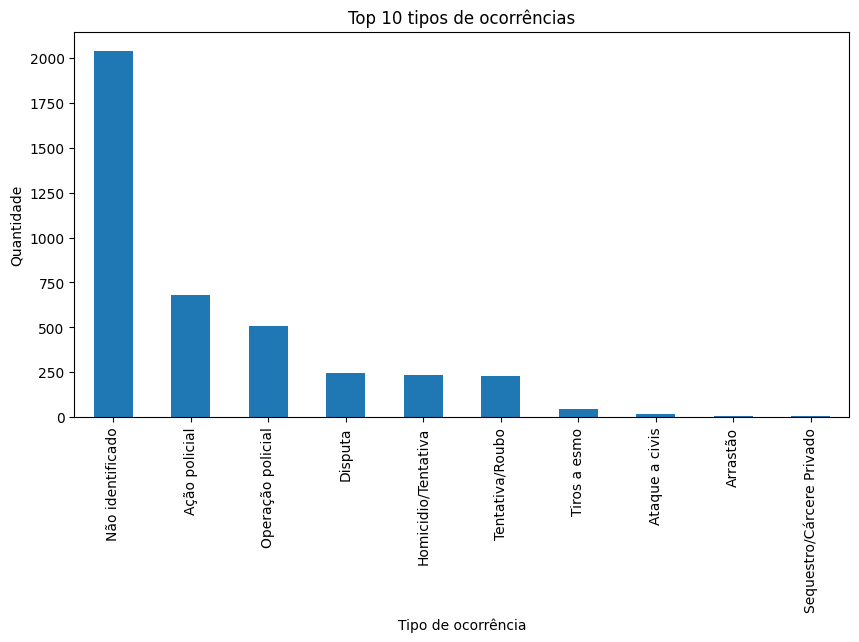

In [ ]:
crimes_df['main_reason'].value_counts().head(10).plot(
    kind = 'bar', figsize=(10,5)
)

plt.title('Top 10 tipos de ocorrências')
plt.xlabel('Tipo de ocorrência')
plt.ylabel('Quantidade')

plt.show()

In [ ]:
crimes_df['neighborhood'].value_counts().head(15)

,count
neighborhood,
PRACA SECA,235
VILA KENNEDY,148
BANGU,116
TANQUE,115
CASCADURA,113
BRAS DE PINA,110
MARE,108
VICENTE DE CARVALHO,107
CAMPINHO,100


In [ ]:
crimes_df['police_action'].value_counts()

,count
police_action,
False,2742
True,1284


In [ ]:
crimes_df['massacre'].value_counts()

,count
massacre,
False,3980
True,46


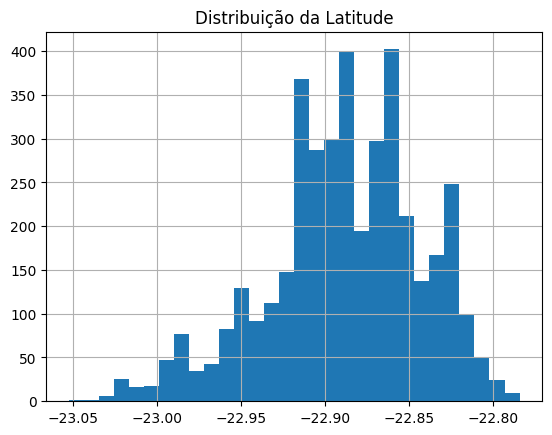

In [ ]:
crimes_df['latitude'].hist(bins=30)

plt.title('Distribuição da Latitude')

plt.show()

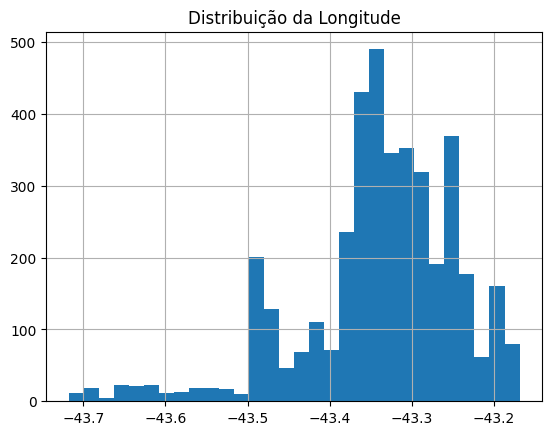

In [ ]:
crimes_df['longitude'].hist(bins=30)

plt.title('Distribuição da Longitude')

plt.show()

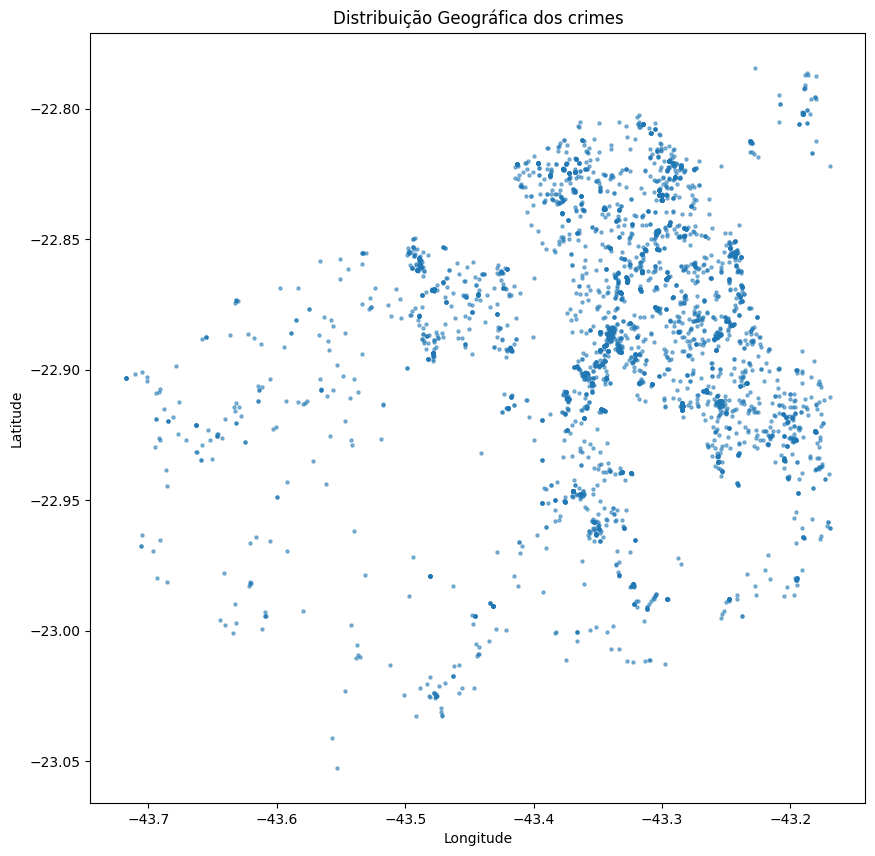

In [ ]:
plt.figure(figsize=(10, 10))

plt.scatter(
    crimes_df['longitude'],
    crimes_df['latitude'],
    alpha=0.5,
    s=5
)

plt.title('Distribuição Geográfica dos crimes')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.show()

Concluímos que "police_action" e "massacre" por serem variáveis booleanas, tem maior utilidade para filtros futuros ou comparação.

Já quanto a "neighborhood" e ao gráfico da distribuição geográfica, fica claro uma grande distribuição espacial (muitos bairros com valores próximos de ocorrências) e uma concentração maior entre as (longitude, latitude) de (-43.4, -22.98) até (-43.2, -22.80)

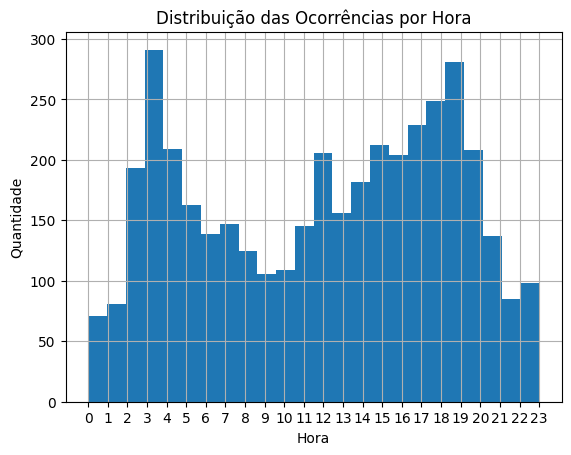

In [ ]:
crimes_df['hora'].hist(bins=24)

plt.title('Distribuição das Ocorrências por Hora')
plt.xlabel('Hora')
plt.ylabel('Quantidade')

plt.xticks(range(24))

plt.show()

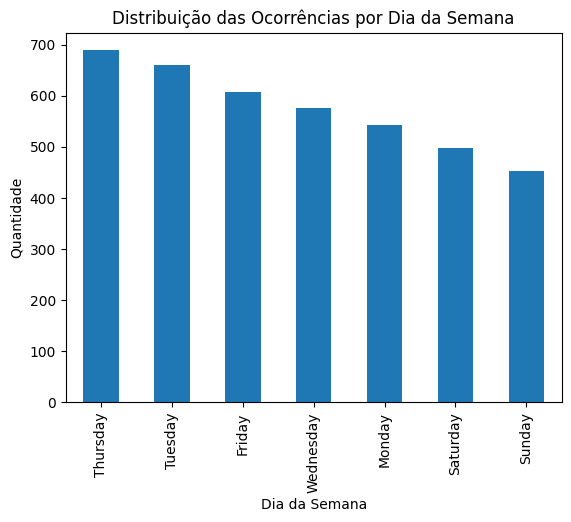

In [ ]:
crimes_df['dia_semana'].value_counts().plot(kind = 'bar')

plt.title('Distribuição das Ocorrências por Dia da Semana')
plt.xlabel('Dia da Semana')
plt.ylabel('Quantidade')

plt.show()

Concluímos então que tem maiores ocorrências de Quarta a Sexta (sendo Quinta-feira o maior dia). E entre 15h até 20h ou 2h até 5h.

# Analisando o dataset de paradas

Início da análise do datset stops_df


In [ ]:
stops_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 485884 entries, 0 to 485883
Data columns (total 19 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   feed_version         485884 non-null  object 
 1   feed_start_date      485884 non-null  object 
 2   feed_end_date        479637 non-null  object 
 3   stop_id              485884 non-null  object 
 4   stop_code            30528 non-null   object 
 5   stop_name            480094 non-null  object 
 6   tts_stop_name        0 non-null       float64
 7   stop_desc            24451 non-null   object 
 8   stop_lat             479719 non-null  float64
 9   stop_lon             479719 non-null  float64
 10  zone_id              0 non-null       float64
 11  stop_url             0 non-null       float64
 12  location_type        479610 non-null  float64
 13  parent_station       28290 non-null   object 
 14  stop_timezone        0 non-null       float64
 15  wheelchair_boardi

In [ ]:
stops_df[
    stops_df['stop_lat'].isnull()
].shape

(6165, 19)

In [ ]:
#removendo linhas com paradas sem coordenada (como são poucas em relação às 485884, não há perda de generalidade ao remover)

stops_df = stops_df.dropna(subset=['stop_lat', 'stop_lon'])

stops_df[['stop_lat', 'stop_lon']].isnull().sum()

,0
stop_lat,0
stop_lon,0


In [ ]:
#removendo colunas nulas

stops_df = stops_df.drop(
    columns=[
        'tts_stop_name',
        'zone_id',
        'stop_url',
        'stop_timezone',
        'wheelchair_boarding',
        'level_id'
    ]
)

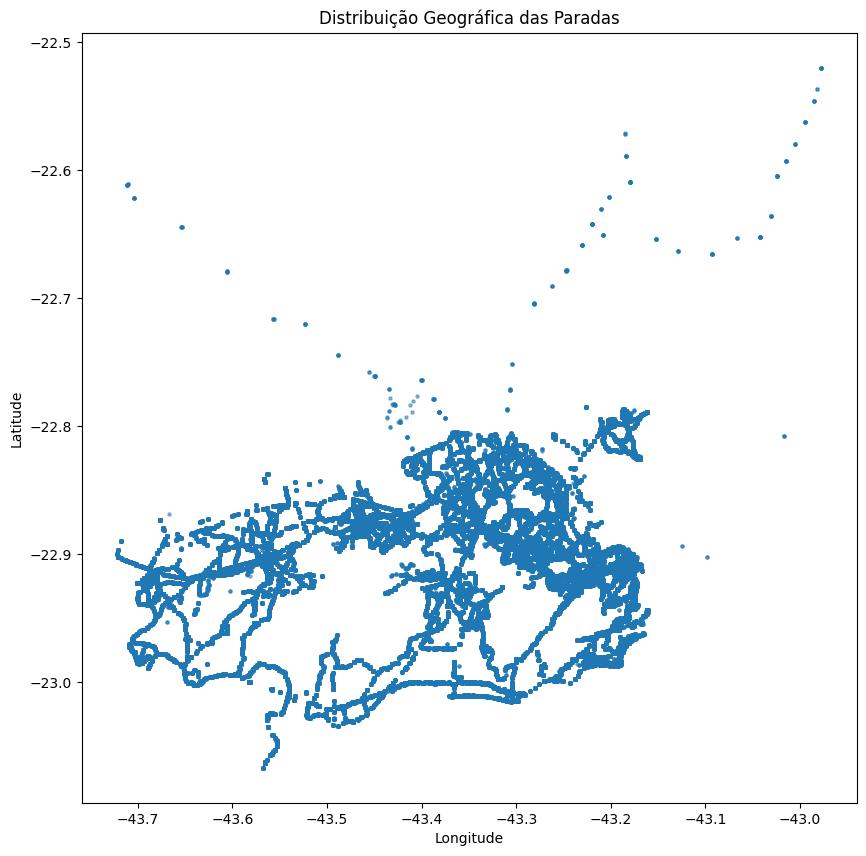

In [ ]:
plt.figure(figsize=(10,10))

plt.scatter(
    stops_df['stop_lon'],
    stops_df['stop_lat'],
    alpha=0.5,
    s=5
)

plt.title('Distribuição Geográfica das Paradas')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.show()

In [ ]:
stops_df['stop_id'].duplicated().sum()

np.int64(470953)

In [ ]:
stops_df['feed_version'].value_counts()

,count
feed_version,
2023-03-01,6497
2023-04-01,6496
2023-03-16,6424
2025-06-01,6338
2025-01-25,6328
...,...
2023-05-01,5889
2023-07-01,5850
2023-06-01,5814


Percebemos que esse dataset não apresenta apenas as rotas mais atuais, por isso mostra tantos dados repetidos. Por isso, vamos filtrar apenas as rotas atuais.

In [ ]:
stops_df['feed_version'].max()

'2026-03-28'

In [ ]:
#Filtrando o dataset para conter apenas as rotas atuais

feed_recente = stops_df['feed_version'].max()

stops_df = stops_df[stops_df['feed_version'] == feed_recente]

In [ ]:
stops_df['stop_id'].duplicated().sum()

np.int64(0)

In [ ]:
stops_df.shape

(6247, 13)

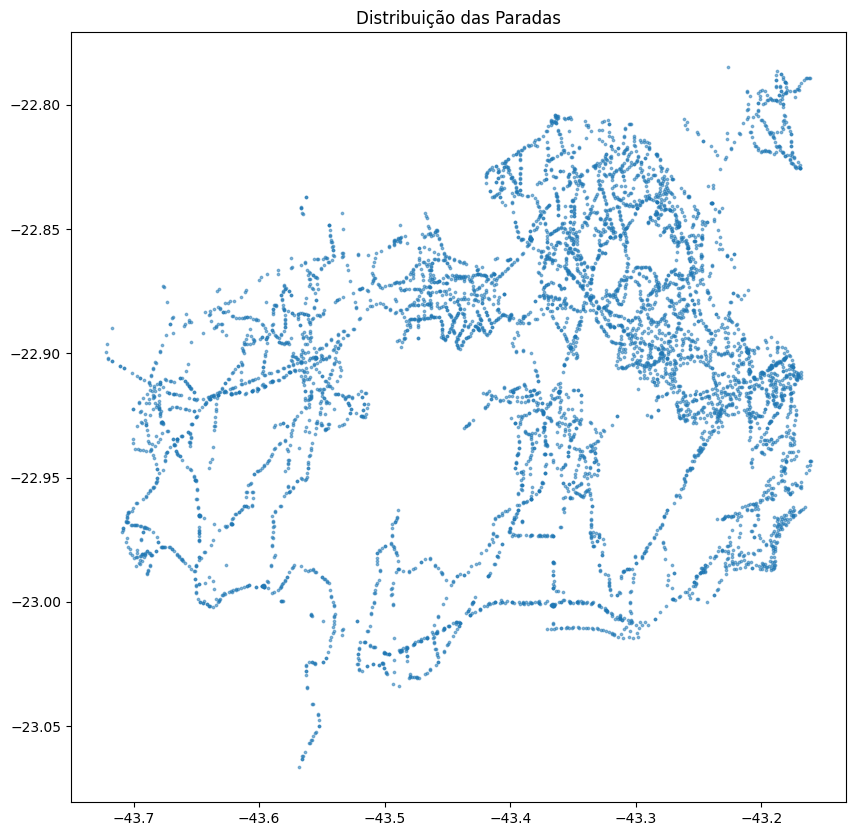

In [ ]:
plt.figure(figsize=(10,10))

plt.scatter(
    stops_df['stop_lon'],
    stops_df['stop_lat'],
    s=3,
    alpha=0.5
)

plt.title('Distribuição das Paradas')

plt.show()

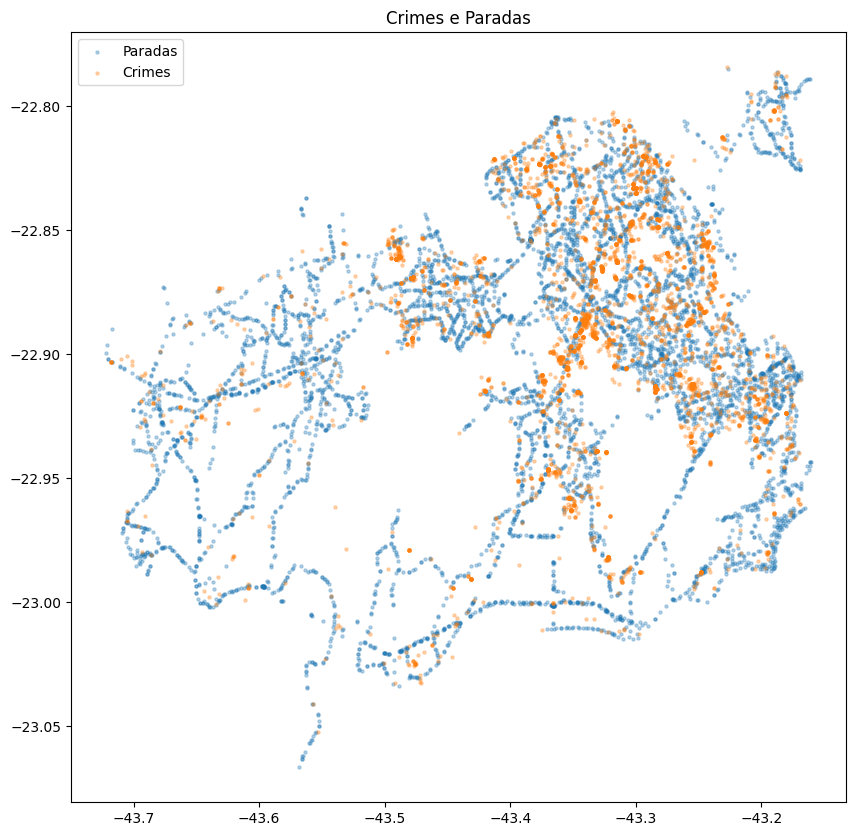

In [ ]:
#Plotar CRIMES + PARADAS

plt.figure(figsize=(10,10))

plt.scatter(
    stops_df['stop_lon'],
    stops_df['stop_lat'],
    s=5,
    alpha=0.3,
    label='Paradas'
)

plt.scatter(
    crimes_df['longitude'],
    crimes_df['latitude'],
    s=5,
    alpha=0.3,
    label='Crimes'
)

plt.legend()

plt.title('Crimes e Paradas')

plt.show()

# Analisando o dataset de viagens

Início da análise do dataset trips_df.


In [ ]:
trips_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 556360 entries, 0 to 556359
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   feed_version           556360 non-null  object 
 1   feed_start_date        556360 non-null  object 
 2   feed_end_date          550453 non-null  object 
 3   route_id               556360 non-null  object 
 4   service_id             556360 non-null  object 
 5   trip_id                556360 non-null  object 
 6   trip_headsign          555908 non-null  object 
 7   trip_short_name        556360 non-null  object 
 8   direction_id           556351 non-null  float64
 9   block_id               0 non-null       float64
 10  shape_id               556359 non-null  object 
 11  wheelchair_accessible  0 non-null       float64
 12  bikes_allowed          0 non-null       float64
 13  versao_modelo          556360 non-null  object 
dtypes: float64(4), object(10)
memory usa

In [ ]:
trips_df['shape_id'].isnull().sum()

np.int64(1)

In [ ]:
trips_df = trips_df.dropna(subset=['shape_id'])

In [ ]:
#filtrar feed mais recente das trips

feed_recente = trips_df['feed_version'].max()

trips_df = trips_df[
    trips_df['feed_version'] == feed_recente
]

In [ ]:
trips_df.shape

(5907, 14)

In [ ]:
#provavelmente o número real de linhas de onibus

trips_df['route_id'].nunique()

488

In [ ]:
#removendo colunas nulas

trips_df = trips_df.drop(columns=[
    'feed_end_date',
    'block_id',
    'wheelchair_accessible',
    'bikes_allowed'
])

In [ ]:
trips_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5907 entries, 74 to 556337
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   feed_version     5907 non-null   object 
 1   feed_start_date  5907 non-null   object 
 2   route_id         5907 non-null   object 
 3   service_id       5907 non-null   object 
 4   trip_id          5907 non-null   object 
 5   trip_headsign    5907 non-null   object 
 6   trip_short_name  5907 non-null   object 
 7   direction_id     5907 non-null   float64
 8   shape_id         5907 non-null   object 
 9   versao_modelo    5907 non-null   object 
dtypes: float64(1), object(9)
memory usage: 507.6+ KB


# Analisando o dataset geográfico das linhas

Início da análise do geom_df.

In [ ]:
geom_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13946 entries, 0 to 13945
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   feed_version     13946 non-null  object 
 1   feed_start_date  13946 non-null  object 
 2   feed_end_date    13732 non-null  object 
 3   shape_id         13946 non-null  object 
 4   shape            13946 non-null  object 
 5   shape_distance   13946 non-null  float64
 6   start_pt         13946 non-null  object 
 7   end_pt           13946 non-null  object 
 8   versao_modelo    13946 non-null  object 
dtypes: float64(1), object(8)
memory usage: 980.7+ KB


In [ ]:
#filtrar pelo shape id

geom_df = geom_df[
    geom_df['shape_id'].isin(trips_df['shape_id'])
]

Fitramos o geom_df pelo shape_id do trips_df para manter apenasas geometrias das rotas que realmente estão em uso no sistema atual.

# Analisando o dataset das rotas

Início da análise do routes_df.

In [ ]:
routes_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37240 entries, 0 to 37239
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   feed_version         37240 non-null  object 
 1   feed_start_date      37240 non-null  object 
 2   feed_end_date        36722 non-null  object 
 3   route_id             37240 non-null  object 
 4   agency_id            37240 non-null  int64  
 5   route_short_name     37240 non-null  object 
 6   route_long_name      37240 non-null  object 
 7   route_desc           6863 non-null   object 
 8   route_type           36834 non-null  float64
 9   route_url            0 non-null      float64
 10  route_color          36807 non-null  object 
 11  route_text_color     36807 non-null  object 
 12  route_sort_order     0 non-null      float64
 13  continuous_pickup    0 non-null      float64
 14  continuous_drop_off  0 non-null      float64
 15  network_id           0 non-null     

In [ ]:
#filtrar o feed mais recente das rotas

feed_recente = routes_df['feed_version'].max()

routes_df = routes_df[
    routes_df['feed_version'] == feed_recente
]

In [ ]:
#removenndo colunas nulas

routes_df = routes_df.drop(columns=[
    'route_url',
    'route_sort_order',
    'continuous_pickup',
    'continuous_drop_off',
    'network_id'
])

# Análise dos preços

In [ ]:
precos_df = pd.read_csv('/content/drive/MyDrive/Projeto_Analytica_PS26/fare_attributes.csv')
fare_types = pd.read_csv('/content/drive/MyDrive/Projeto_Analytica_PS26/fare_rules.csv')

In [ ]:
precos_df.head()

,feed_version,feed_start_date,feed_end_date,fare_id,price,currency_type,payment_method,transfers,agency_id,transfer_duration,versao_modelo
0,2024-03-18,2024-03-18,2024-03-29,BUC_IN,4.30,BRL,0,1.0,22003.0,NaN,201d79faee763526a030ff998bebea9782efe961
1,2024-03-18,2024-03-18,2024-03-29,BUC_IS,4.30,BRL,0,1.0,22002.0,NaN,201d79faee763526a030ff998bebea9782efe961
2,2024-03-18,2024-03-18,2024-03-29,BUC_SC,4.30,BRL,0,1.0,22005.0,NaN,201d79faee763526a030ff998bebea9782efe961
3,2024-03-18,2024-03-18,2024-03-29,BUC_TC,4.30,BRL,0,1.0,22004.0,NaN,201d79faee763526a030ff998bebea9782efe961
4,2024-03-18,2024-03-18,2024-03-29,EXEC_A_IN,13.35,BRL,0,0.0,22003.0,NaN,201d79faee763526a030ff998bebea9782efe961


In [ ]:
fare_types.tail()

,feed_version,feed_start_date,feed_end_date,fare_id,route_id,origin_id,destination_id,contains_id,versao_modelo
20262,2025-12-21,2025-12-21,2025-12-26,EXEC_D_SC_TP,E2335AAA0A_TP,NaN,NaN,NaN,22d4617d5bb2889f600112473f926c3a35f27ed9
20263,2025-12-21,2025-12-21,2025-12-26,EXEC_D_SC_TP,E2337AAA0A_TP,NaN,NaN,NaN,22d4617d5bb2889f600112473f926c3a35f27ed9
20264,2025-12-21,2025-12-21,2025-12-26,EXEC_D_TC_TP,E2114AAA0A_TP,NaN,NaN,NaN,22d4617d5bb2889f600112473f926c3a35f27ed9
20265,2025-12-21,2025-12-21,2025-12-26,EXEC_D_TC_TP,E2112AAA0A_TP,NaN,NaN,NaN,22d4617d5bb2889f600112473f926c3a35f27ed9
20266,2025-12-21,2025-12-21,2025-12-26,EXEC_D_TC_TP,E2111AAA0A_TP,NaN,NaN,NaN,22d4617d5bb2889f600112473f926c3a35f27ed9


In [ ]:
precos_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1023 entries, 0 to 1022
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   feed_version       1023 non-null   object 
 1   feed_start_date    1023 non-null   object 
 2   feed_end_date      1001 non-null   object 
 3   fare_id            1023 non-null   object 
 4   price              1023 non-null   float64
 5   currency_type      1023 non-null   object 
 6   payment_method     1023 non-null   int64  
 7   transfers          917 non-null    float64
 8   agency_id          1021 non-null   float64
 9   transfer_duration  0 non-null      float64
 10  versao_modelo      1023 non-null   object 
dtypes: float64(4), int64(1), object(6)
memory usage: 88.0+ KB


In [ ]:
fare_types.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20267 entries, 0 to 20266
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   feed_version     20267 non-null  object 
 1   feed_start_date  20267 non-null  object 
 2   feed_end_date    19748 non-null  object 
 3   fare_id          20267 non-null  object 
 4   route_id         20267 non-null  object 
 5   origin_id        0 non-null      float64
 6   destination_id   0 non-null      float64
 7   contains_id      0 non-null      float64
 8   versao_modelo    20267 non-null  object 
dtypes: float64(3), object(6)
memory usage: 1.4+ MB


In [ ]:
#principais estatísticas dos preços
precos_df['price'].describe().T

,price
count,1023.000000
mean,14.275367
std,8.035564
min,4.300000
25%,4.700000
50%,16.600000
75%,21.650000
max,24.850000


In [ ]:
#procurando valores nulos nos arquivos

print("valores nulos nos arquivos\n")
print(f"precos:\n{precos_df.isnull().sum()}\n")
print(f"tipos:\n{fare_types.isnull().sum()}\n")
#nenhuma id de fare ou id de rota nan

valores nulos nos arquivos

precos:
feed_version            0
feed_start_date         0
feed_end_date          22
fare_id                 0
price                   0
currency_type           0
payment_method          0
transfers             106
agency_id               2
transfer_duration    1023
versao_modelo           0
dtype: int64

tipos:
feed_version           0
feed_start_date        0
feed_end_date        519
fare_id                0
route_id               0
origin_id          20267
destination_id     20267
contains_id        20267
versao_modelo          0
dtype: int64



In [ ]:
#procurando valores duplicados
precos_df.isna().sum()
precos_df['fare_id'].duplicated().value_counts()



,count
fare_id,
True,997
False,26


In [ ]:
#muitos valores de fare_id duplicados: pegar apenas os mais recentes

precos_df['feed_version'] = pd.to_datetime(precos_df['feed_version'], format='%Y-%m-%d')
precos_df = precos_df.sort_values(by='feed_version', ascending=False)
precos_df = precos_df.drop_duplicates(subset='fare_id', keep='first').reset_index()

fare_types['feed_version'] = pd.to_datetime(fare_types['feed_version'], format='%Y-%m-%d')
fare_types = fare_types.sort_values(by='feed_version', ascending=False)
fare_types = fare_types.drop_duplicates(subset='route_id', keep='first').reset_index()



In [ ]:
precos_df = precos_df[['fare_id','price']]
precos_df

,fare_id,price
0,BRT_Metro,6.70
1,EXEC_B_TC,21.65
2,BRT_Exec,15.00
3,BUC_SC,5.00
4,BUC_TC,5.00
5,BUC_IN,5.00
6,BUC_IS,5.00
7,EXEC_C_SC_TP,20.00
8,EXEC_D_SC_TP,23.00
9,EXEC_C_TC_TP,20.00


In [ ]:
fare_types = fare_types[['route_id','fare_id']]
fare_types

,route_id,fare_id
0,O0950AAA0A,BUC_IN
1,O0863AAA0A,BUC_TC
2,O0555AAA0A,BUC_TC
3,O0810AAA0A,BUC_TC
4,O0636AAA0A,BUC_TC
...,...,...
608,SE008,BRT_Rir
609,SE009,BRT_Rir
610,E2801AAA0A,EXEC_C_SC
611,O0550FLA0A,BUC_TC


In [ ]:
#merge do id da rota e do preco

route_price = fare_types.merge(precos_df, on='fare_id', how='left')
route_price

,route_id,fare_id,price
0,O0950AAA0A,BUC_IN,5.00
1,O0863AAA0A,BUC_TC,5.00
2,O0555AAA0A,BUC_TC,5.00
3,O0810AAA0A,BUC_TC,5.00
4,O0636AAA0A,BUC_TC,5.00
...,...,...,...
608,SE008,BRT_Rir,23.00
609,SE009,BRT_Rir,23.00
610,E2801AAA0A,EXEC_C_SC,24.85
611,O0550FLA0A,BUC_TC,5.00


# Estimando a qualidade da linha

Ar condicionado


In [ ]:
ar_df = pd.read_csv('/content/drive/MyDrive/Projeto_Analytica_PS26/sppo_licenciamento_solicitacao.csv')
ar_df
viagens_df = pd.read_csv('/content/drive/MyDrive/Projeto_Analytica_PS26/viagem_informada.csv')

In [ ]:
print(f"id_veiculo ar_df:\n {ar_df['id_veiculo'].duplicated().value_counts()}\n")
print(f"id_veiculo viagens_df:\n {viagens_df['id_veiculo'].duplicated().value_counts()}\n")
print(f"route_id viagens_df: \n{viagens_df['route_id'].duplicated().value_counts()}\n")
print(f"linhas duplicadas viagens_df: \n{viagens_df[['id_veiculo','route_id']].duplicated().value_counts()}\n")
print(f"linhas duplicadas viagens_df: \n{viagens_df['id_viagem'].duplicated().value_counts()}\n")

id_veiculo ar_df:
 id_veiculo
False    2007
Name: count, dtype: int64

id_veiculo viagens_df:
 id_veiculo
True     251862
False      4863
Name: count, dtype: int64

route_id viagens_df: 
route_id
True     255778
False       947
Name: count, dtype: int64

linhas duplicadas viagens_df: 
True     212279
False     44446
Name: count, dtype: int64

linhas duplicadas viagens_df: 
id_viagem
False    256725
Name: count, dtype: int64



Cada rota ultiliza diferentes onibus em diversas viagens:
Para descobrir quais rotas tem chances mais altas de terem a condicinado, vamos fazer uma media


In [ ]:
# filtrando as infromacoes mais relevantes e as que o Status é Válido
ar_df = ar_df[['data', 'id_veiculo', 'ano_fabricacao','quantidade_lotacao_pe' ,'quantidade_lotacao_sentado', 'status' ,'indicador_ar_condicionado', 'indicador_elevador']]
ar_df = ar_df[ar_df['status']== 'Válido']
ar_df

,data,id_veiculo,ano_fabricacao,quantidade_lotacao_pe,quantidade_lotacao_sentado,status,indicador_ar_condicionado,indicador_elevador
109,2023-02-06,C30126,2010,NaN,NaN,Válido,False,NaN
110,2023-02-06,D13203,2010,NaN,NaN,Válido,False,NaN
111,2023-02-06,C47455,2010,NaN,NaN,Válido,False,NaN
112,2023-02-06,B10079,2010,NaN,NaN,Válido,False,NaN
113,2023-02-06,C47770,2010,NaN,NaN,Válido,False,NaN
...,...,...,...,...,...,...,...,...
2002,2023-02-06,A72135,2018,NaN,NaN,Válido,True,NaN
2003,2023-02-06,A72137,2018,NaN,NaN,Válido,True,NaN
2004,2023-02-06,D13011,2019,NaN,NaN,Válido,True,NaN
2005,2023-02-06,C72155,2019,NaN,NaN,Válido,True,NaN


In [ ]:
ar_df.isnull().sum()
ar_df = ar_df[['data', 'id_veiculo', 'ano_fabricacao', 'indicador_ar_condicionado']]
ar_df['indicador_ar_condicionado'] = ar_df['indicador_ar_condicionado'].astype(int)
ar_df

/tmp/ipykernel_10959/2649656178.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ar_df['indicador_ar_condicionado'] = ar_df['indicador_ar_condicionado'].astype(int)


,data,id_veiculo,ano_fabricacao,indicador_ar_condicionado
109,2023-02-06,C30126,2010,0
110,2023-02-06,D13203,2010,0
111,2023-02-06,C47455,2010,0
112,2023-02-06,B10079,2010,0
113,2023-02-06,C47770,2010,0
...,...,...,...,...
2002,2023-02-06,A72135,2018,1
2003,2023-02-06,A72137,2018,1
2004,2023-02-06,D13011,2019,1
2005,2023-02-06,C72155,2019,1


In [ ]:
viagens_df = viagens_df[['data', 'datetime_partida', 'datetime_chegada', 'id_veiculo', 'route_id']]
viagens_df['data_viagem'] = viagens_df['data']
viagens_df = viagens_df[['data_viagem', 'datetime_partida', 'datetime_chegada', 'id_veiculo', 'route_id']]

#criar uma coluna com a duracao de cada viagem

viagens_df['datetime_partida'] = pd.to_datetime(viagens_df['datetime_partida'])
viagens_df['datetime_chegada'] = pd.to_datetime(viagens_df['datetime_chegada'])
viagens_df['duracao_viagem'] = (viagens_df['datetime_chegada'] - viagens_df['datetime_partida']).astype(str).str.split().str[-1]
viagens_df['data_viagem'] = pd.to_datetime(viagens_df['data_viagem'], format='%Y-%m-%d')



In [ ]:
# criando o dataset viagens_df com as informacoes mais relevantes (relaciona as rotas com os veiculos e viagens)
dataset_viagens = viagens_df[['data_viagem', 'id_veiculo', 'route_id', 'duracao_viagem']].merge(ar_df,on='id_veiculo', how='left')
dataset_viagens

,data_viagem,id_veiculo,route_id,duracao_viagem,data,ano_fabricacao,indicador_ar_condicionado
0,2026-02-25,A71544,O0409AAA0A,01:02:30,NaN,NaN,NaN
1,2024-12-08,B10003,186,01:10:59,2023-02-06,2015.0,1.0
2,2025-09-19,D13012,O0383AAA0A,01:45:30,NaN,NaN,NaN
3,2025-06-27,A48056,O0202AAA0A,00:18:24,NaN,NaN,NaN
4,2025-02-19,C47638,O0390AAA0A,02:12:00,NaN,NaN,NaN
...,...,...,...,...,...,...,...
256720,2024-12-13,A50086,301,01:23:28,2023-02-06,2015.0,1.0
256721,2025-09-10,A27584,O0548AAA0A,01:27:30,NaN,NaN,NaN
256722,2025-08-25,B51537,O0917AAA0A,01:31:28,NaN,NaN,NaN
256723,2025-01-24,D87127,O0869AAA0A,00:17:55,NaN,NaN,NaN


In [ ]:
dataset_viagens.isnull().sum()

,0
data_viagem,0
id_veiculo,289
route_id,1003
duracao_viagem,0
data,229525
ano_fabricacao,229525
indicador_ar_condicionado,229525


In [ ]:
# tirando os valores nulos
dataset_viagens = dataset_viagens.dropna(subset=['route_id', 'data', 'id_veiculo'])

dataset_viagens.info()


<class 'pandas.core.frame.DataFrame'>
Index: 27073 entries, 1 to 256720
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   data_viagem                27073 non-null  datetime64[ns]
 1   id_veiculo                 27073 non-null  object        
 2   route_id                   27073 non-null  object        
 3   duracao_viagem             27073 non-null  object        
 4   data                       27073 non-null  object        
 5   ano_fabricacao             27073 non-null  float64       
 6   indicador_ar_condicionado  27073 non-null  float64       
dtypes: datetime64[ns](1), float64(2), object(4)
memory usage: 1.7+ MB


Vaos definir agora a taxa de onibus com ar condicionado, duração média e ano de fabricacao médio por rota

In [ ]:
# fazendo as médias

dataset_viagens['duracao_viagem'] = pd.to_timedelta(dataset_viagens['duracao_viagem'])
dataset_viagens['duracao_viagem'] = dataset_viagens['duracao_viagem'].dt.total_seconds() / 60


dataset_viagens = dataset_viagens.groupby('route_id')[['indicador_ar_condicionado','duracao_viagem','ano_fabricacao']].mean().reset_index()

# formatando os numeros
def duas_casas(numero):
    return '{:.2f}'.format(numero)

def porcentagem(numero):
    return '{:.1%}'.format(numero)

dataset_viagens['indicador_ar_condicionado'] = dataset_viagens['indicador_ar_condicionado'].apply(porcentagem)
dataset_viagens['ano_fabricacao'] = dataset_viagens['ano_fabricacao'].apply(duas_casas)
dataset_viagens['duracao_viagem'] = dataset_viagens['duracao_viagem'].apply(duas_casas)

dataset_viagens

/tmp/ipykernel_10959/237773153.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset_viagens['duracao_viagem'] = pd.to_timedelta(dataset_viagens['duracao_viagem'])
/tmp/ipykernel_10959/237773153.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset_viagens['duracao_viagem'] = dataset_viagens['duracao_viagem'].dt.total_seconds() / 60


,route_id,indicador_ar_condicionado,duracao_viagem,ano_fabricacao
0,100,0.0%,84.20,2010.00
1,114,0.0%,77.88,2011.00
2,116,0.0%,90.02,2012.00
3,117,9.5%,125.45,2011.90
4,118,8.3%,75.60,2011.88
...,...,...,...,...
547,O0987AAA0A,5.9%,24.46,2010.53
548,O0990AAA0A,0.0%,27.02,2010.00
549,ZRX,100.0%,106.50,2010.00
550,ZRX1,0.0%,125.58,2010.00


# Unindo os datasets

Juntando datasets sobre as linhas, paradas e crimes.

In [ ]:
import geopandas as gpd
from shapely import wkt

#1. Separando somente as colunas essenciais de cada dataset, e mantendo apenas a última versão de cada entidade

stops_slim = stops_df.sort_values('feed_version') \
    .drop_duplicates('stop_id', keep='last') \
    [['stop_id', 'stop_name', 'stop_lat', 'stop_lon']]

geom_slim = geom_df[
    geom_df['shape_id'].isin(trips_df['shape_id'])
][['shape_id', 'shape']].drop_duplicates()

trips_slim = trips_df.sort_values('feed_version') \
    .drop_duplicates('shape_id', keep='last') \
    [['shape_id', 'route_id']]

routes_slim = routes_df.sort_values('feed_version') \
    .drop_duplicates('route_id', keep='last') \
    [['route_id', 'route_short_name', 'route_long_name']]

crimes_slim = crimes_df[['id', 'neighborhood', 'latitude', 'longitude', 'mes','hora','dia_semana', 'main_reason']]

# 2. Juntando as informações sobre as linhas: linhas_raw = geom + trips + routes

linhas_slim = geom_slim \
    .merge(trips_slim,  on='shape_id',  how='left') \
    .merge(routes_slim, on='route_id',  how='left')

print('linhas_slim:', linhas_slim.shape)
print('stops_slim: ', stops_slim.shape)
print('crimes_slim:', crimes_slim.shape)

linhas_slim: (2300, 5)
stops_slim:  (6247, 4)
crimes_slim: (4026, 8)


In [ ]:
#Criando os Geodataframes para cada dataset
linhas_slim['geometry'] = linhas_slim['shape'].apply(wkt.loads)
gdf_linhas = gpd.GeoDataFrame(linhas_slim, geometry='geometry', crs='EPSG:4326')

stops_slim['geometry'] = gpd.points_from_xy(stops_slim['stop_lon'], stops_slim['stop_lat'])
gdf_stops = gpd.GeoDataFrame(stops_slim, geometry='geometry', crs='EPSG:4326')

crimes_slim['geometry'] = gpd.points_from_xy(crimes_slim['longitude'], crimes_slim['latitude'])
gdf_crimes = gpd.GeoDataFrame(crimes_slim, geometry='geometry', crs='EPSG:4326')


#Passando as distâncias para metros
gdf_linhas = gdf_linhas.to_crs('EPSG:31983')
gdf_stops = gdf_stops.to_crs('EPSG:31983')
gdf_crimes = gdf_crimes.to_crs('EPSG:31983')

/tmp/ipykernel_10959/271352742.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  crimes_slim['geometry'] = gpd.points_from_xy(crimes_slim['longitude'], crimes_slim['latitude'])


In [ ]:
#Criando buffers de 50 metros para as linhas
gdf_linhas_buf = gdf_linhas.copy()
gdf_linhas_buf['geometry'] = gdf_linhas_buf.geometry.buffer(50)

#Verificando quais paradas estão dentro dos buffers das linhas
paradas_linhas = gpd.sjoin(
    gdf_stops,
    gdf_linhas_buf,
    how='left',
    predicate='within'
)

#Criando um buffer de 500 metros para as paradas
gdf_stops_buf = gdf_stops.copy()
gdf_stops_buf['geometry'] = gdf_stops_buf.geometry.buffer(500)

#Verificando quais crimes estão dentro dos buffers das paradas
crimes_paradas = gpd.sjoin(
    gdf_crimes,
    gdf_stops_buf,
    how='left',
    predicate='within'
)

In [ ]:
#Calculando o total de crimes por parada
score_paradas = crimes_paradas.groupby('stop_id').size().reset_index(name='total_crimes')

#Adicionando a contagem de crimes ao dataframe de paradas_linhas
paradas_linhas = paradas_linhas.merge(score_paradas, on='stop_id', how='left').fillna(0)
paradas_linhas.head(3)


,stop_id,stop_name,stop_lat,stop_lon,geometry,index_right,shape_id,shape,route_id,route_short_name,route_long_name,total_crimes
0,5144O00357C9,Pompílio da Rocha,-22.89388,-43.56499,POINT (647187.531 7467510.456),1154.0,O0851AAA0AIDU01,"MULTILINESTRING((-43.5465 -22.90211, -43.54652...",O0851AAA0A,851,Campo Grande - Escola Amazonas,0.0
1,2035O00066C0,Maracanã - Acesso Leste,-22.91351,-43.22771,POINT (681762.835 7464959.859),1.0,9ptt,"MULTILINESTRING((-43.29031 -22.90076, -43.2902...",O0232AAA0A,232,Lins de Vasconcelos - Castelo,8.0
2,2035O00066C0,Maracanã - Acesso Leste,-22.91351,-43.22771,POINT (681762.835 7464959.859),54.0,hu05,"MULTILINESTRING((-43.19089 -22.9867, -43.19082...",O0455AAA0A,455,Méier - Copacabana,8.0


In [ ]:
#Criando o dataset agrupando por linha de ônibus e criando features
dataset_agregado = paradas_linhas.groupby('route_short_name').agg(
    n_paradas         = ('stop_id', 'nunique'),
    crimes_medio      = ('total_crimes', 'mean'),
    crimes_max        = ('total_crimes', 'max'),
    crimes_total      = ('total_crimes', 'sum'),
    pct_sem_crime     = ('total_crimes', lambda x: (x <= 1).mean() * 100),
).reset_index().round(2)

dataset_agregado.head(10)

,route_short_name,n_paradas,crimes_medio,crimes_max,crimes_total,pct_sem_crime
0,0,21,3.29,9.0,69.0,33.33
1,006,49,5.81,21.0,1093.0,25.53
2,007,58,5.87,21.0,1661.0,28.27
3,10,213,0.88,5.0,971.0,77.03
4,100,119,2.50,10.0,1199.0,28.81
5,104,265,3.31,20.0,5605.0,34.12
6,107,91,2.48,8.0,586.0,28.81
7,11,213,0.86,5.0,970.0,77.11
8,117,28,4.84,17.0,218.0,15.56
9,12,165,0.91,5.0,251.0,75.00


Unindo as rotas com o preço

In [ ]:
route_price = routes_slim.merge(route_price,on='route_id',how='left')
route_price

,route_id,route_short_name,route_long_name,fare_id,price
0,E2110AAA0A,2110,Gardênia Azul - Castelo,EXEC_B_TC,21.65
1,O0853AAN0A,SN853,Terminal Mato Alto - Terminal Deodoro,BUC_SC,5.00
2,O0849AAA0A,849,Base Aérea de Santa Cruz - Campo Grande,BUC_SC,5.00
3,O0786AAA0A,786,Terminal Campo Grande - Cascadura,BUC_SC,5.00
4,O0918AAA0A,918,Bangu - Bonsucesso,BUC_SC,5.00
...,...,...,...,...,...
513,O0296AAA0A,296,Irajá - Castelo,BUC_IN,5.00
514,O0232AAA0A,232,Lins de Vasconcelos - Castelo,BUC_IN,5.00
515,O0779AAA0A,779,Metrô Pavuna - Terminal Madureira,BUC_IN,5.00
516,O0484AAA0A,484,Olaria - General Osório,BUC_IN,5.00


In [ ]:
dataset_agregado = dataset_agregado.merge(route_price[['route_short_name','price']], on='route_short_name',how='left')
dataset_agregado

,route_short_name,n_paradas,crimes_medio,crimes_max,crimes_total,pct_sem_crime,price
0,0,21,3.29,9.0,69.0,33.33,NaN
1,006,49,5.81,21.0,1093.0,25.53,5.0
2,007,58,5.87,21.0,1661.0,28.27,5.0
3,10,213,0.88,5.0,971.0,77.03,5.0
4,100,119,2.50,10.0,1199.0,28.81,5.0
...,...,...,...,...,...,...,...
478,SV917,191,5.04,77.0,4625.0,30.86,5.0
479,SV921,63,1.76,7.0,197.0,50.00,5.0
480,SV922,37,0.67,3.0,140.0,80.95,5.0
481,SVB665,182,8.99,39.0,9768.0,11.79,5.0


In [ ]:
preco_medio = dataset_agregado['price'].mean()
dataset_agregado = dataset_agregado.fillna(preco_medio)
dataset_agregado

,route_short_name,n_paradas,crimes_medio,crimes_max,crimes_total,pct_sem_crime,price
0,0,21,3.29,9.0,69.0,33.33,6.501452
1,006,49,5.81,21.0,1093.0,25.53,5.000000
2,007,58,5.87,21.0,1661.0,28.27,5.000000
3,10,213,0.88,5.0,971.0,77.03,5.000000
4,100,119,2.50,10.0,1199.0,28.81,5.000000
...,...,...,...,...,...,...,...
478,SV917,191,5.04,77.0,4625.0,30.86,5.000000
479,SV921,63,1.76,7.0,197.0,50.00,5.000000
480,SV922,37,0.67,3.0,140.0,80.95,5.000000
481,SVB665,182,8.99,39.0,9768.0,11.79,5.000000


### Criando features temporais agregadas por linha de ônibus

In [ ]:
# Para criar features temporais por linha, precisamos agrupar os crimes que foram associados a cada linha.
# 'crimes_paradas' já contém a coluna 'stop_id' e 'paradas_linhas' contém 'stop_id' e 'route_short_name'.

# Selecionar apenas as colunas necessárias de paradas_linhas para evitar colunas duplicadas no merge
# Um crime pode estar perto de uma parada que é servida por múltiplas rotas. Queremos que o crime seja
# contado para cada uma dessas rotas, por isso mantemos as duplicatas de stop_id aqui.
routes_for_stops = paradas_linhas[['stop_id', 'route_short_name']].drop_duplicates()

# Mesclar crimes_paradas com routes_for_stops para ligar crimes às rotas via paradas.
# Um crime será duplicado se a parada próxima for servida por várias rotas.
crimes_with_routes = crimes_paradas.merge(routes_for_stops, on='stop_id', how='left')

# Remover linhas onde nenhuma rota foi associada (crimes que não estão perto de paradas com rotas conhecidas)
crimes_with_routes = crimes_with_routes.dropna(subset=['route_short_name'])

# Agora, crimes_with_routes tem a coluna 'route_short_name'
crimes_paradas_temp = crimes_with_routes.copy()

# Agrupar crimes por linha, dia da semana e hora para obter contagens
crimes_by_route_day = crimes_paradas_temp.groupby(['route_short_name', 'dia_semana']).size().unstack(fill_value=0)
crimes_by_route_hour = crimes_paradas_temp.groupby(['route_short_name', 'hora']).size().unstack(fill_value=0)

# Criar features de resumo para os dias da semana
day_features = pd.DataFrame({
    'crimes_dia_max': crimes_by_route_day.max(axis=1),
    'crimes_dia_min': crimes_by_route_day.min(axis=1),
    'crimes_dia_std': crimes_by_route_day.std(axis=1).fillna(0) # Preencher NaN para rotas com poucos crimes
}).reset_index()
day_features.columns = ['route_short_name', 'crimes_dia_max', 'crimes_dia_min', 'crimes_dia_std']

# Criar features de resumo para as horas
hour_features = pd.DataFrame({
    'crimes_hora_max': crimes_by_route_hour.max(axis=1),
    'crimes_hora_min': crimes_by_route_hour.min(axis=1),
    'crimes_hora_std': crimes_by_route_hour.std(axis=1).fillna(0) # Preencher NaN para rotas com poucos crimes
}).reset_index()
hour_features.columns = ['route_short_name', 'crimes_hora_max', 'crimes_hora_min', 'crimes_hora_std']

# Unir essas novas features ao dataset_agregado
# Atualizar dataset_agregado diretamente
dataset_agregado = dataset_agregado.merge(day_features, on='route_short_name', how='left')
dataset_agregado = dataset_agregado.merge(hour_features, on='route_short_name', how='left')

# Preencher quaisquer NaNs remanescentes com 0 (para rotas sem crimes ou variações)
dataset_agregado = dataset_agregado.fillna(0)

# Atribuir a dataset_ml para consistência com células subsequentes que o utilizam
dataset_ml = dataset_agregado.copy()

display(dataset_ml.head())

,route_short_name,n_paradas,crimes_medio,crimes_max,crimes_total,pct_sem_crime,price,crimes_dia_max,crimes_dia_min,crimes_dia_std,crimes_hora_max,crimes_hora_min,crimes_hora_std
0,0,21,3.29,9.0,69.0,33.33,6.501452,18,2,5.336309,8,0,2.212858
1,006,49,5.81,21.0,1093.0,25.53,5.000000,73,15,19.242809,29,0,9.692276
2,007,58,5.87,21.0,1661.0,28.27,5.000000,73,19,19.303343,37,0,10.956353
3,10,213,0.88,5.0,971.0,77.03,5.000000,48,10,14.360992,30,0,8.933632
4,100,119,2.50,10.0,1199.0,28.81,5.000000,78,12,22.178926,48,0,12.838391


In [ ]:
dataset_agregado

,route_short_name,n_paradas,crimes_medio,crimes_max,crimes_total,pct_sem_crime,price,crimes_dia_max,crimes_dia_min,crimes_dia_std,crimes_hora_max,crimes_hora_min,crimes_hora_std
0,0,21,3.29,9.0,69.0,33.33,6.501452,18,2,5.336309,8,0,2.212858
1,006,49,5.81,21.0,1093.0,25.53,5.000000,73,15,19.242809,29,0,9.692276
2,007,58,5.87,21.0,1661.0,28.27,5.000000,73,19,19.303343,37,0,10.956353
3,10,213,0.88,5.0,971.0,77.03,5.000000,48,10,14.360992,30,0,8.933632
4,100,119,2.50,10.0,1199.0,28.81,5.000000,78,12,22.178926,48,0,12.838391
...,...,...,...,...,...,...,...,...,...,...,...,...,...
478,SV917,191,5.04,77.0,4625.0,30.86,5.000000,252,96,55.488309,126,8,29.421475
479,SV921,63,1.76,7.0,197.0,50.00,5.000000,37,0,13.009154,15,0,4.835707
480,SV922,37,0.67,3.0,140.0,80.95,5.000000,8,0,2.935821,10,0,2.612331
481,SVB665,182,8.99,39.0,9768.0,11.79,5.000000,266,119,50.602560,123,17,29.105381


### Construção do Modelo de Machine Learning e Predição do Nível de Perigo

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split # Added for cross-sectional split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler, StandardScaler # Re-introducing for danger score scaling
from sklearn.metrics import mean_squared_error, r2_score

# ================================
# 1. PREPARAR DADOS PARA MODELAGEM (CROSS-SECTIONAL)
#    Removendo as partes de time-series features que não são aplicáveis
#    à estrutura atual de dataset_ml
# ================================

# O dataset_ml atual é agregado por rota e não possui uma coluna 'data'
# ou uma estrutura de série temporal para cada rota que suporte 'shift' ou 'rolling' diretamente.
# As features temporais no dataset_ml (crimes_dia_max, crimes_hora_max, etc.) são sumarizações
# da distribuição de crimes ao longo do tempo para cada rota, e não pontos de tempo sequenciais.

# Definir as features (X) e o target (y)
# O target será 'crimes_total' que usaremos para criar o score de perigo
X = dataset_ml.drop(columns=[
    'route_short_name',
    'crimes_medio', # crimes_medio é derivado do total, pode causar vazamento
    'crimes_max',   # similarmente, pode ser muito correlacionado
    'crimes_total'  # Esta é a variável alvo
])
y = dataset_ml['crimes_total']

# Aplicar Standard Scaler nas features X
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X)
X = pd.DataFrame(X_scaled, columns=X.columns)

# ================================
# 2. SPLIT DOS DADOS (TREINO/TESTE)
# ================================

# Usar train_test_split para dados cross-seccionais
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ================================
# 3. TREINAR MODELO
# ================================

model = RandomForestRegressor(
    n_estimators=100, # Ajustado para o modelo RandomForestRegressor
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

# ================================
# 4. AVALIAÇÃO
# ================================

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f'RMSE: {rmse:.2f}')
print(f'R²: {r2:.2f}')

# ================================
# 5. PREDIÇÃO COMPLETA E SCORE DE PERIGO (0–100)
# ================================

full_predictions = model.predict(X) # Prever para o dataset completo

# Escalonar as previsões para um score de 0 a 100 usando MinMaxScaler
scaler_danger_score = MinMaxScaler(feature_range=(0, 100))
# Usar y (crimes_total) para fitar o MinMaxScaler para garantir que o range de 0-100 reflita a distribuição original de crimes.
scaler_danger_score.fit(y.to_frame())

dataset_ml['nivel_perigo_score'] = scaler_danger_score.transform(full_predictions.reshape(-1, 1)).flatten().round(2)

# ================================
# 6. RESULTADOS
# ================================

print("\n MAIS PERIGOSAS:")
display(dataset_ml.sort_values(by='nivel_perigo_score', ascending=False).head())

print("\n MAIS SEGURAS:")
display(dataset_ml.sort_values(by='nivel_perigo_score', ascending=True).head())

# ================================
# 7. IMPORTÂNCIA DAS FEATURES
# ================================

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values(by='importance', ascending=False)

print("\n FEATURES MAIS IMPORTANTES:")
display(feature_importance.head(10))

RMSE: 1548.55
R²: 0.72

 MAIS PERIGOSAS:


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


,route_short_name,n_paradas,crimes_medio,crimes_max,crimes_total,pct_sem_crime,price,crimes_dia_max,crimes_dia_min,crimes_dia_std,crimes_hora_max,crimes_hora_min,crimes_hora_std,nivel_perigo_score
141,46,247,14.44,87.0,23980.0,21.07,5.0,570,335,85.852032,268,37,63.955360,74.15
117,371,210,13.61,87.0,10715.0,9.40,5.0,553,411,54.302942,274,45,63.605085,60.85
111,355,207,9.81,39.0,15222.0,9.15,5.0,359,168,74.125376,184,21,39.961372,54.20
382,SN355,208,9.56,39.0,13339.0,9.03,5.0,363,163,76.327615,186,21,40.090026,53.80
197,636,225,14.67,87.0,16060.0,11.05,5.0,475,346,53.462938,221,33,50.689146,53.36



 MAIS SEGURAS:


,route_short_name,n_paradas,crimes_medio,crimes_max,crimes_total,pct_sem_crime,price,crimes_dia_max,crimes_dia_min,crimes_dia_std,crimes_hora_max,crimes_hora_min,crimes_hora_std,nivel_perigo_score
156,513,22,0.11,2.0,4.0,94.59,5.0,1,0,0.487950,1,0,0.282330,0.03
283,844,21,0.33,2.0,21.0,90.48,5.0,4,0,1.732051,3,0,0.806450,0.08
317,893,50,0.44,4.0,22.0,96.00,5.0,6,0,2.478479,7,0,2.062431,0.09
423,SN893,50,0.44,4.0,22.0,96.00,5.0,6,0,2.478479,7,0,2.062431,0.09
269,826,43,0.58,3.0,39.0,95.52,5.0,6,2,1.732051,6,0,1.926174,0.12



 FEATURES MAIS IMPORTANTES:


,feature,importance
3,crimes_dia_max,0.535093
4,crimes_dia_min,0.161994
8,crimes_hora_std,0.085918
5,crimes_dia_std,0.057140
1,pct_sem_crime,0.047915
0,n_paradas,0.041824
7,crimes_hora_min,0.034051
6,crimes_hora_max,0.030033
2,price,0.006032


In [ ]:
dataset_agregado = dataset_agregado.merge(dataset_ml[['route_short_name','nivel_perigo_score']], on='route_short_name',how='left')
dataset_agregado

,route_short_name,n_paradas,crimes_medio,crimes_max,crimes_total,pct_sem_crime,price,crimes_dia_max,crimes_dia_min,crimes_dia_std,crimes_hora_max,crimes_hora_min,crimes_hora_std,nivel_perigo_score
0,0,21,3.29,9.0,69.0,33.33,6.501452,18,2,5.336309,8,0,2.212858,0.48
1,006,49,5.81,21.0,1093.0,25.53,5.000000,73,15,19.242809,29,0,9.692276,3.96
2,007,58,5.87,21.0,1661.0,28.27,5.000000,73,19,19.303343,37,0,10.956353,5.63
3,10,213,0.88,5.0,971.0,77.03,5.000000,48,10,14.360992,30,0,8.933632,3.80
4,100,119,2.50,10.0,1199.0,28.81,5.000000,78,12,22.178926,48,0,12.838391,4.63
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
478,SV917,191,5.04,77.0,4625.0,30.86,5.000000,252,96,55.488309,126,8,29.421475,17.06
479,SV921,63,1.76,7.0,197.0,50.00,5.000000,37,0,13.009154,15,0,4.835707,0.89
480,SV922,37,0.67,3.0,140.0,80.95,5.000000,8,0,2.935821,10,0,2.612331,0.51
481,SVB665,182,8.99,39.0,9768.0,11.79,5.000000,266,119,50.602560,123,17,29.105381,29.78


# Construção do Modelo de cluster

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

#Selecionando as features
features = ['n_paradas', 'crimes_medio', 'crimes_max', 'crimes_total', 'pct_sem_crime']

#Escalonando as features
scaler = StandardScaler()
X = dataset_agregado[features]
X_scaled = scaler.fit_transform(X)


#Criando o modelo
modelo_cluster = KMeans(n_clusters=3, random_state=42, n_init=10)
dataset_agregado['cluster'] = modelo_cluster.fit_predict(X_scaled)

print(dataset_agregado.groupby('cluster')[X.columns].mean().round(2))
print('\nLinhas por cluster:')
print(dataset_agregado['cluster'].value_counts())

         n_paradas  crimes_medio  crimes_max  crimes_total  pct_sem_crime
cluster                                                                  
0           124.87          5.24       28.82       2161.38          26.62
1           127.19          1.35        8.72        677.14          72.41
2           219.51          7.68       53.85       6704.31          21.85

Linhas por cluster:
cluster
0    216
1    149
2    118
Name: count, dtype: int64


In [ ]:
#Nomeando os clusters

mapa_clusters = {
    0: 'Médio Risco',
    2: 'Alto Risco',
    1: 'Baixo Risco'
}

dataset_agregado['perfil_risco'] = dataset_agregado['cluster'].map(mapa_clusters)
dataset_agregado.drop(axis=1, columns='cluster')

,route_short_name,n_paradas,crimes_medio,crimes_max,crimes_total,pct_sem_crime,price,crimes_dia_max,crimes_dia_min,crimes_dia_std,crimes_hora_max,crimes_hora_min,crimes_hora_std,nivel_perigo_score,perfil_risco
0,0,21,3.29,9.0,69.0,33.33,6.501452,18,2,5.336309,8,0,2.212858,0.48,Médio Risco
1,006,49,5.81,21.0,1093.0,25.53,5.000000,73,15,19.242809,29,0,9.692276,3.96,Médio Risco
2,007,58,5.87,21.0,1661.0,28.27,5.000000,73,19,19.303343,37,0,10.956353,5.63,Médio Risco
3,10,213,0.88,5.0,971.0,77.03,5.000000,48,10,14.360992,30,0,8.933632,3.80,Baixo Risco
4,100,119,2.50,10.0,1199.0,28.81,5.000000,78,12,22.178926,48,0,12.838391,4.63,Médio Risco
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
478,SV917,191,5.04,77.0,4625.0,30.86,5.000000,252,96,55.488309,126,8,29.421475,17.06,Alto Risco
479,SV921,63,1.76,7.0,197.0,50.00,5.000000,37,0,13.009154,15,0,4.835707,0.89,Baixo Risco
480,SV922,37,0.67,3.0,140.0,80.95,5.000000,8,0,2.935821,10,0,2.612331,0.51,Baixo Risco
481,SVB665,182,8.99,39.0,9768.0,11.79,5.000000,266,119,50.602560,123,17,29.105381,29.78,Alto Risco


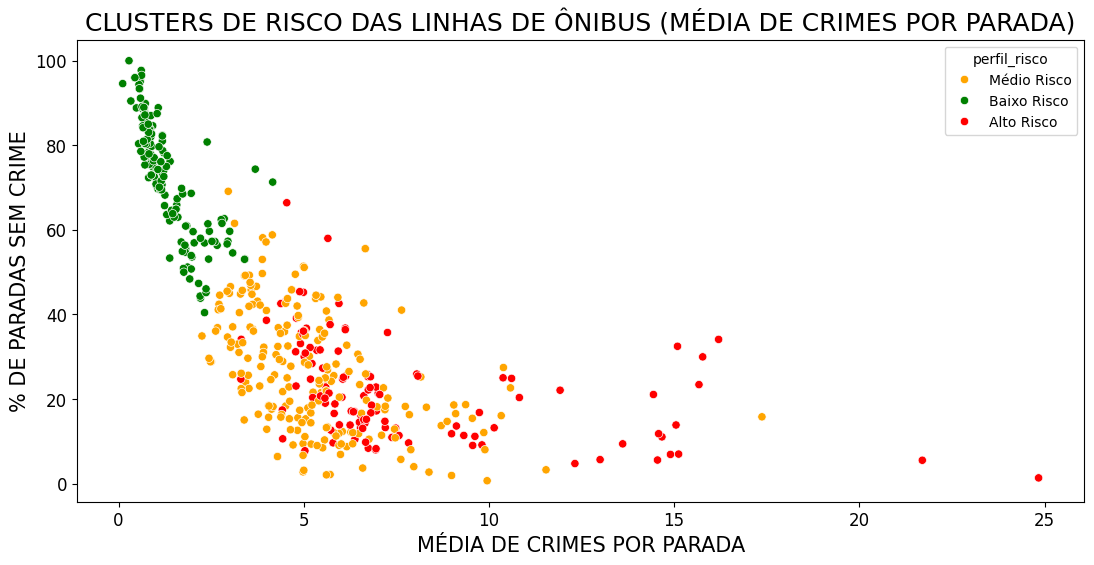

In [ ]:
#Analisando os clusters visualmente
plt.figure(figsize=(13, 6))
sns.scatterplot(
    data=dataset_agregado,
    x='crimes_medio',
    y='pct_sem_crime',
    hue='perfil_risco',
    palette={'Alto Risco': 'red', 'Médio Risco': 'orange', 'Baixo Risco': 'green'}
)

plt.title('CLUSTERS DE RISCO DAS LINHAS DE ÔNIBUS (MÉDIA DE CRIMES POR PARADA)', fontsize=18)
plt.xlabel('MÉDIA DE CRIMES POR PARADA', fontsize=15)
plt.ylabel('% DE PARADAS SEM CRIME', fontsize=15)

# Ajustando o tamanho da fonte dos números
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Exibe o gráfico
plt.show()

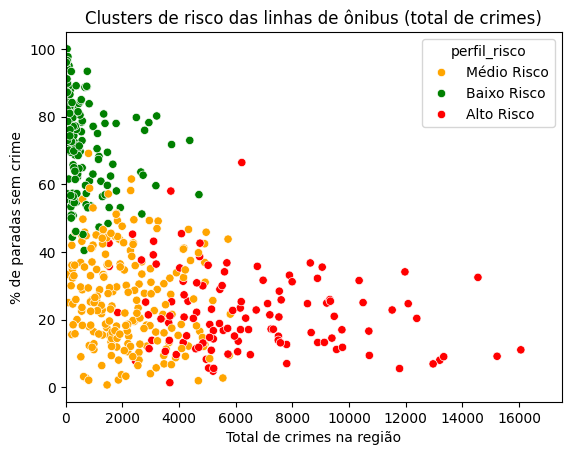

In [ ]:
#Vendo os clusters visualmente

sns.scatterplot(
    data=dataset_agregado,
    x='crimes_total',
    y='pct_sem_crime',
    hue='perfil_risco',
    palette={'Alto Risco': 'red', 'Médio Risco': 'orange', 'Baixo Risco': 'green'}
)

plt.title('Clusters de risco das linhas de ônibus (total de crimes)')
plt.xlabel('Total de crimes na região')
plt.ylabel('% de paradas sem crime')
plt.xlim(0,17500)
plt.show()

# Análise dos dados de dataset_agregado

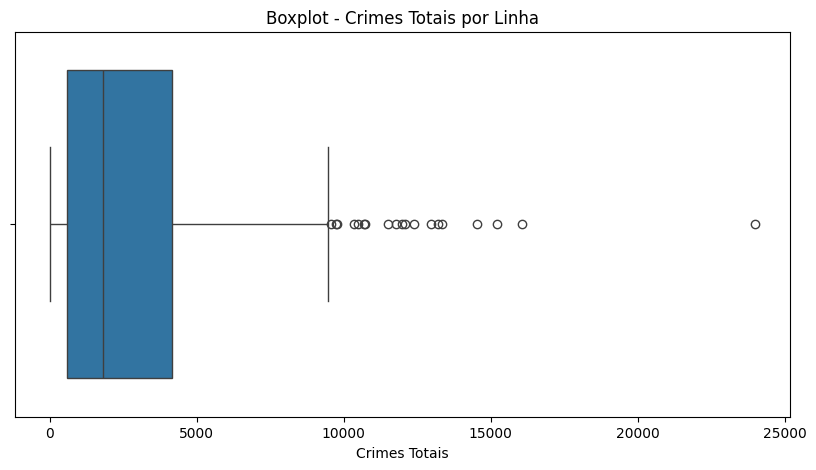

In [ ]:
plt.figure(figsize=(10,5))
sns.boxplot(x=dataset_agregado['crimes_total'])

plt.title('Boxplot - Crimes Totais por Linha')
plt.xlabel('Crimes Totais')
plt.show()

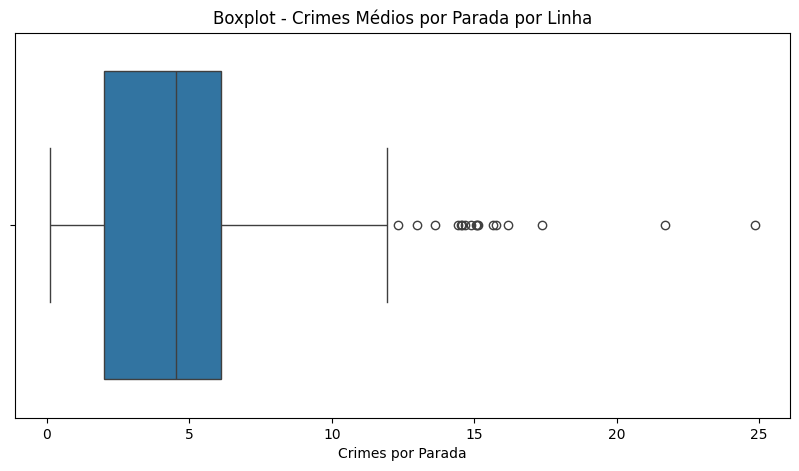

In [ ]:
plt.figure(figsize=(10,5))
sns.boxplot(x=dataset_agregado['crimes_medio'])




plt.title('Boxplot - Crimes Médios por Parada por Linha')
plt.xlabel('Crimes por Parada')
plt.show()

/tmp/ipykernel_10959/185652600.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


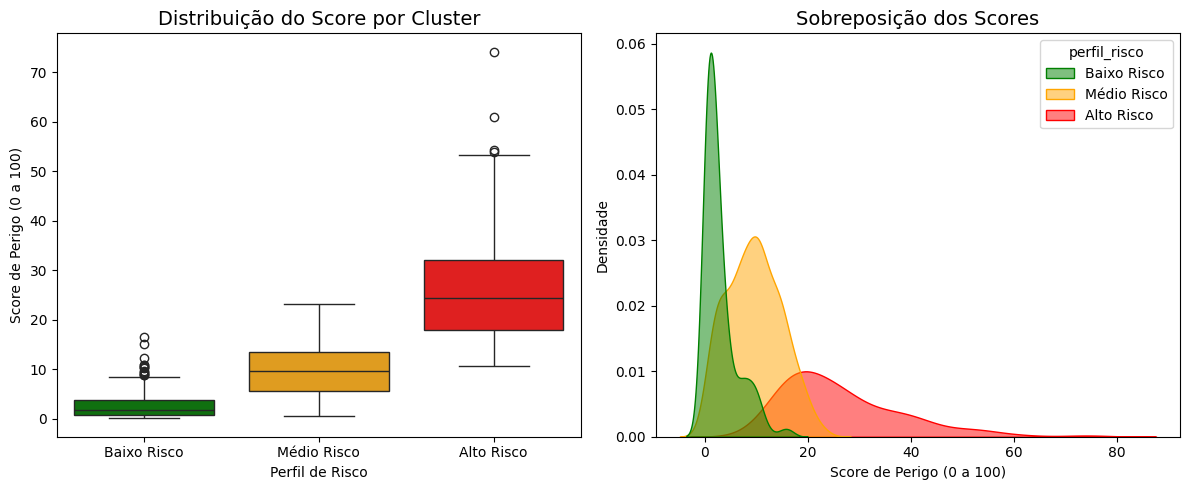

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))

# Gráfico 1: Boxplot
plt.subplot(1, 2, 1)
sns.boxplot(
    data=dataset_agregado,
    x='perfil_risco',
    y='nivel_perigo_score',
    order=['Baixo Risco', 'Médio Risco', 'Alto Risco'],
    palette=['green', 'orange', 'red']
)
plt.title('Distribuição do Score por Cluster', fontsize=14)
plt.xlabel('Perfil de Risco')
plt.ylabel('Score de Perigo (0 a 100)')

# Gráfico 2: Curva de Densidade (KDE)
plt.subplot(1, 2, 2)
sns.kdeplot(
    data=dataset_agregado,
    x='nivel_perigo_score',
    hue='perfil_risco',
    hue_order=['Baixo Risco', 'Médio Risco', 'Alto Risco'],
    palette=['green', 'orange', 'red'],
    fill=True,
    alpha=0.5
)
plt.title('Sobreposição dos Scores', fontsize=14)
plt.xlabel('Score de Perigo (0 a 100)')
plt.ylabel('Densidade')

plt.tight_layout()
plt.show()

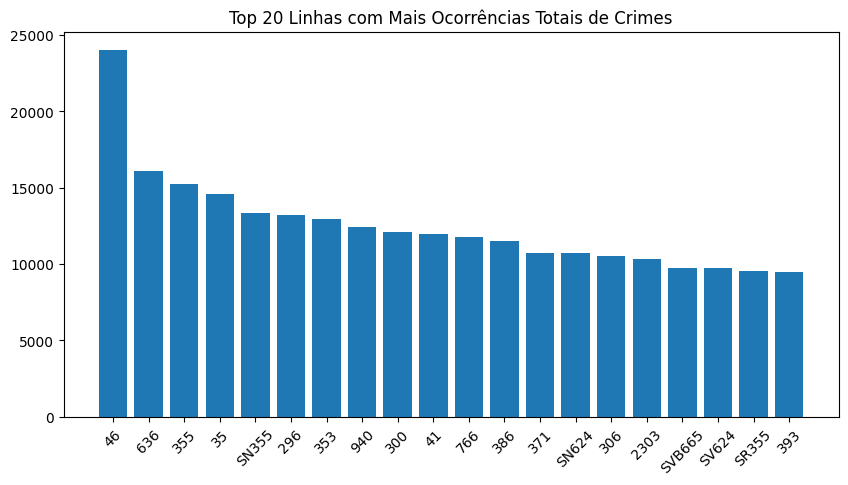

In [ ]:
plt.figure(figsize=(10,5))
top20 = dataset_agregado.sort_values('crimes_total', ascending=False).head(20)


plt.bar(top20['route_short_name'], top20['crimes_total'])
plt.xticks(rotation=45)
plt.title('Top 20 Linhas com Mais Ocorrências Totais de Crimes')
plt.show()

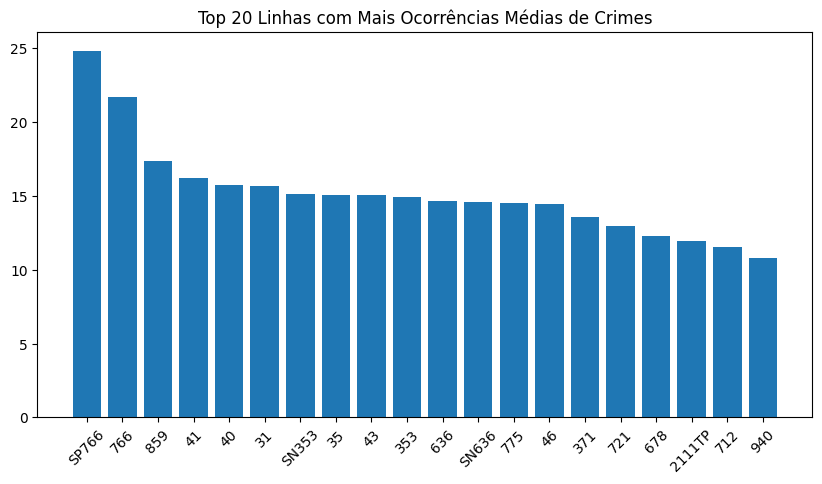

In [ ]:
plt.figure(figsize=(10,5))
top20 = dataset_agregado.sort_values('crimes_medio', ascending=False).head(20)


plt.bar(top20['route_short_name'], top20['crimes_medio'])
plt.xticks(rotation=45)
plt.title('Top 20 Linhas com Mais Ocorrências Médias de Crimes')
plt.show()

### Integrar Características de Qualidade dos Ônibus

Vamos mesclar o `dataset_viagens` (que contém o indicador de ar condicionado, duração média e ano de fabricação por rota) ao `dataset_agregado`. Isso adicionará informações valiosas sobre a qualidade das linhas ao nosso conjunto de dados para análise e modelagem.

In [ ]:
dataset_viagens = dataset_viagens.merge(routes_slim[['route_id', 'route_short_name']], on='route_id', how='left')
dataset_agregado = dataset_agregado.merge(dataset_viagens, on='route_short_name', how='left')

# Preencher valores NaN para as novas colunas com as médias globais, se apropriado, ou 0 se a ausência significar a não ocorrência.
# Por exemplo, para indicador_ar_condicionado, NaN pode significar que não há dados, então preencher com a média é razoável.
# Para ano_fabricacao, a média também seria uma boa imputação.
# Para duracao_viagem, a média também.

# Convertendo a coluna 'indicador_ar_condicionado' para float para preenchimento de NaN
# Primeiro, remover o '%' e converter para float, depois dividir por 100
dataset_agregado['indicador_ar_condicionado'] = dataset_agregado['indicador_ar_condicionado'].astype(str).str.replace('%', '', regex=False).astype(float) / 100

# Converter 'ano_fabricacao' e 'duracao_viagem' para numérico antes de preencher
dataset_agregado['ano_fabricacao'] = dataset_agregado['ano_fabricacao'].astype(str).str.replace(',', '.', regex=False).astype(float)
dataset_agregado['duracao_viagem'] = dataset_agregado['duracao_viagem'].astype(str).str.replace(',', '.', regex=False).astype(float)

# Preencher NaNs com a média das respectivas colunas
dataset_agregado['indicador_ar_condicionado'].fillna(dataset_agregado['indicador_ar_condicionado'].mean(), inplace=True)
dataset_agregado['ano_fabricacao'].fillna(dataset_agregado['ano_fabricacao'].mean(), inplace=True)
dataset_agregado['duracao_viagem'].fillna(dataset_agregado['duracao_viagem'].mean(), inplace=True)

display(dataset_agregado.head())

/tmp/ipykernel_10959/4117321367.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset_agregado['indicador_ar_condicionado'].fillna(dataset_agregado['indicador_ar_condicionado'].mean(), inplace=True)
/tmp/ipykernel_10959/4117321367.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as 

,route_short_name,n_paradas,crimes_medio,crimes_max,crimes_total,pct_sem_crime,price,crimes_dia_max,crimes_dia_min,crimes_dia_std,crimes_hora_max,crimes_hora_min,crimes_hora_std,nivel_perigo_score,cluster,perfil_risco,route_id,indicador_ar_condicionado,duracao_viagem,ano_fabricacao
0,0,21,3.29,9.0,69.0,33.33,6.501452,18,2,5.336309,8,0,2.212858,0.48,0,Médio Risco,NaN,0.454803,59.403333,2012.90521
1,006,49,5.81,21.0,1093.0,25.53,5.000000,73,15,19.242809,29,0,9.692276,3.96,0,Médio Risco,O0006AAA0A,1.000000,32.240000,2018.00000
2,007,58,5.87,21.0,1661.0,28.27,5.000000,73,19,19.303343,37,0,10.956353,5.63,0,Médio Risco,O0007AAA0A,1.000000,36.570000,2017.65000
3,10,213,0.88,5.0,971.0,77.03,5.000000,48,10,14.360992,30,0,8.933632,3.80,1,Baixo Risco,NaN,0.454803,59.403333,2012.90521
4,100,119,2.50,10.0,1199.0,28.81,5.000000,78,12,22.178926,48,0,12.838391,4.63,0,Médio Risco,O0100AAA0A,0.990000,42.450000,2016.18000


In [ ]:
dataset_agregado

,route_short_name,n_paradas,crimes_medio,crimes_max,crimes_total,pct_sem_crime,price,crimes_dia_max,crimes_dia_min,crimes_dia_std,crimes_hora_max,crimes_hora_min,crimes_hora_std,nivel_perigo_score,cluster,perfil_risco,route_id,indicador_ar_condicionado,duracao_viagem,ano_fabricacao
0,0,21,3.29,9.0,69.0,33.33,6.501452,18,2,5.336309,8,0,2.212858,0.48,0,Médio Risco,NaN,0.454803,59.403333,2012.90521
1,006,49,5.81,21.0,1093.0,25.53,5.000000,73,15,19.242809,29,0,9.692276,3.96,0,Médio Risco,O0006AAA0A,1.000000,32.240000,2018.00000
2,007,58,5.87,21.0,1661.0,28.27,5.000000,73,19,19.303343,37,0,10.956353,5.63,0,Médio Risco,O0007AAA0A,1.000000,36.570000,2017.65000
3,10,213,0.88,5.0,971.0,77.03,5.000000,48,10,14.360992,30,0,8.933632,3.80,1,Baixo Risco,NaN,0.454803,59.403333,2012.90521
4,100,119,2.50,10.0,1199.0,28.81,5.000000,78,12,22.178926,48,0,12.838391,4.63,0,Médio Risco,O0100AAA0A,0.990000,42.450000,2016.18000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
478,SV917,191,5.04,77.0,4625.0,30.86,5.000000,252,96,55.488309,126,8,29.421475,17.06,2,Alto Risco,O0917AAV0A,1.000000,103.340000,2017.00000
479,SV921,63,1.76,7.0,197.0,50.00,5.000000,37,0,13.009154,15,0,4.835707,0.89,1,Baixo Risco,O0921AAV0A,1.000000,24.880000,2015.00000
480,SV922,37,0.67,3.0,140.0,80.95,5.000000,8,0,2.935821,10,0,2.612331,0.51,1,Baixo Risco,O0922AAV0A,0.109000,31.910000,2012.30000
481,SVB665,182,8.99,39.0,9768.0,11.79,5.000000,266,119,50.602560,123,17,29.105381,29.78,2,Alto Risco,O0665AAVBA,0.111000,78.340000,2010.47000


Assim, garantimos que essas novas colunas estão prontas para a análise, também foram ajustados os tipos de cada coluna e substituídos os valores ausentes (Nan) pela média global de cada coluna. Dessa forma, ao adicionar ao dataset_agregado enriquecemos as informações de cada linha de ônibus com um perfil mais completo. Nos permitindo, por exemplo, investigar se linhas com ônibus mais novos ou com mais ar condicionado têm um perfil de risco diferente, ou se durações de viagem mais longas estão associadas a mais crimes. Isso torna o nosso modelo e as características dos clusters mais abrangentes e realistas.

### Refinar Features Temporais

Podemos criar features mais granulares a partir dos dados de crimes por hora e dia da semana para capturar padrões específicos de risco.

In [ ]:
# Recalcular crimes_by_route_hour e crimes_by_route_day para garantir que 'crimes_with_routes' seja a base

# Já calculamos 'crimes_by_route_hour' e 'crimes_by_route_day' anteriormente.
# Vamos extrair novas features a partir deles.

# Features para horários de pico (ex: 6-9h, 17-20h)
crimes_with_routes['hora_pico_manha'] = crimes_with_routes['hora'].apply(lambda x: 1 if 6 <= x <= 9 else 0)
crimes_with_routes['hora_pico_tarde'] = crimes_with_routes['hora'].apply(lambda x: 1 if 17 <= x <= 20 else 0)
crimes_with_routes['hora_noturna'] = crimes_with_routes['hora'].apply(lambda x: 1 if (21 <= x <= 23) or (0 <= x <= 5) else 0)

crimes_pico_manha_by_route = crimes_with_routes.groupby('route_short_name')['hora_pico_manha'].sum().reset_index(name='crimes_pico_manha')
crimes_pico_tarde_by_route = crimes_with_routes.groupby('route_short_name')['hora_pico_tarde'].sum().reset_index(name='crimes_pico_tarde')
crimes_noturnos_by_route = crimes_with_routes.groupby('route_short_name')['hora_noturna'].sum().reset_index(name='crimes_noturnos')

# Features para dias de semana vs. fim de semana
crimes_with_routes['is_weekend'] = crimes_with_routes['dia_semana'].isin(['Saturday', 'Sunday']).astype(int)
crimes_fim_semana_by_route = crimes_with_routes.groupby('route_short_name')['is_weekend'].sum().reset_index(name='crimes_fim_semana')

# List of columns to be merged
new_temporal_cols = ['crimes_pico_manha', 'crimes_pico_tarde', 'crimes_noturnos', 'crimes_fim_semana']

# Drop existing temporal crime columns from dataset_agregado if they exist,
# to avoid conflicts during merge, especially if the cell was run previously.
for col in new_temporal_cols:
    if col in dataset_agregado.columns:
        dataset_agregado = dataset_agregado.drop(columns=[col])
    # Also check for suffixed versions that might cause the MergeError
    if f'{col}_x' in dataset_agregado.columns:
        dataset_agregado = dataset_agregado.drop(columns=[f'{col}_x'])
    if f'{col}_y' in dataset_agregado.columns:
        dataset_agregado = dataset_agregado.drop(columns=[f'{col}_y'])


# Unir ao dataset_agregado
dataset_agregado = dataset_agregado.merge(crimes_pico_manha_by_route, on='route_short_name', how='left').fillna(0)
dataset_agregado = dataset_agregado.merge(crimes_pico_tarde_by_route, on='route_short_name', how='left').fillna(0)
dataset_agregado = dataset_agregado.merge(crimes_noturnos_by_route, on='route_short_name', how='left').fillna(0)
dataset_agregado = dataset_agregado.merge(crimes_fim_semana_by_route, on='route_short_name', how='left').fillna(0)

display(dataset_agregado.head())

,route_short_name,n_paradas,crimes_medio,crimes_max,crimes_total,pct_sem_crime,price,crimes_dia_max,crimes_dia_min,crimes_dia_std,...,cluster,perfil_risco,route_id,indicador_ar_condicionado,duracao_viagem,ano_fabricacao,crimes_pico_manha,crimes_pico_tarde,crimes_noturnos,crimes_fim_semana
0,0,21,3.29,9.0,69.0,33.33,6.501452,18,2,5.336309,...,0,Médio Risco,0,0.454803,59.403333,2012.90521,7,13,25,11
1,006,49,5.81,21.0,1093.0,25.53,5.000000,73,15,19.242809,...,0,Médio Risco,O0006AAA0A,1.000000,32.240000,2018.00000,54,65,121,40
2,007,58,5.87,21.0,1661.0,28.27,5.000000,73,19,19.303343,...,0,Médio Risco,O0007AAA0A,1.000000,36.570000,2017.65000,60,70,134,44
3,10,213,0.88,5.0,971.0,77.03,5.000000,48,10,14.360992,...,1,Baixo Risco,0,0.454803,59.403333,2012.90521,2,58,45,52
4,100,119,2.50,10.0,1199.0,28.81,5.000000,78,12,22.178926,...,0,Médio Risco,O0100AAA0A,0.990000,42.450000,2016.18000,58,102,78,61


In [ ]:
# Re-executing the regression cross-validation after dataset updates
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Definir as features (X) e o target (y) novamente com as novas colunas
features = [
    'n_paradas',
    'pct_sem_crime',
    'price',
    'crimes_dia_max',
    'crimes_dia_min',
    'crimes_dia_std',
    'crimes_hora_max',
    'crimes_hora_min',
    'crimes_hora_std',
    'indicador_ar_condicionado',
    'ano_fabricacao',
    'duracao_viagem',
    'crimes_pico_manha',
    'crimes_pico_tarde',
    'crimes_noturnos',
    'crimes_fim_semana'
]
y = dataset_agregado['crimes_total']
X = dataset_agregado[features]

# Escalar as features
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X)
X = pd.DataFrame(X_scaled, columns=X.columns)

# Configuração da Validação Cruzada
kf = KFold(n_splits=5, shuffle=True, random_state=42)

rmse_scores = []
r2_scores = []

# Executar a Validação Cruzada
for fold, (train_index, test_index) in enumerate(kf.split(X, y)):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    rmse_scores.append(rmse)
    r2_scores.append(r2)

    print(f"Fold {fold+1}: RMSE = {rmse:.2f}, R² = {r2:.2f}")

print(f"\nMédia RMSE: {np.mean(rmse_scores):.2f} (Std: {np.std(rmse_scores):.2f})")
print(f"Média R²: {np.mean(r2_scores):.2f} (Std: {np.std(r2_scores):.2f})")

Fold 1: RMSE = 1436.81, R² = 0.76
Fold 2: RMSE = 2300.67, R² = 0.58
Fold 3: RMSE = 1779.57, R² = 0.66
Fold 4: RMSE = 1986.75, R² = 0.56
Fold 5: RMSE = 1412.27, R² = 0.69

Média RMSE: 1783.21 (Std: 336.69)
Média R²: 0.65 (Std: 0.07)


In [ ]:
dataset_agregado

,route_short_name,n_paradas,crimes_medio,crimes_max,crimes_total,pct_sem_crime,price,crimes_dia_max,crimes_dia_min,crimes_dia_std,...,cluster,perfil_risco,route_id,indicador_ar_condicionado,duracao_viagem,ano_fabricacao,crimes_pico_manha,crimes_pico_tarde,crimes_noturnos,crimes_fim_semana
0,0,21,3.29,9.0,69.0,33.33,6.501452,18,2,5.336309,...,0,Médio Risco,0,0.454803,59.403333,2012.90521,7,13,25,11
1,006,49,5.81,21.0,1093.0,25.53,5.000000,73,15,19.242809,...,0,Médio Risco,O0006AAA0A,1.000000,32.240000,2018.00000,54,65,121,40
2,007,58,5.87,21.0,1661.0,28.27,5.000000,73,19,19.303343,...,0,Médio Risco,O0007AAA0A,1.000000,36.570000,2017.65000,60,70,134,44
3,10,213,0.88,5.0,971.0,77.03,5.000000,48,10,14.360992,...,1,Baixo Risco,0,0.454803,59.403333,2012.90521,2,58,45,52
4,100,119,2.50,10.0,1199.0,28.81,5.000000,78,12,22.178926,...,0,Médio Risco,O0100AAA0A,0.990000,42.450000,2016.18000,58,102,78,61
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
478,SV917,191,5.04,77.0,4625.0,30.86,5.000000,252,96,55.488309,...,2,Alto Risco,O0917AAV0A,1.000000,103.340000,2017.00000,85,366,270,304
479,SV921,63,1.76,7.0,197.0,50.00,5.000000,37,0,13.009154,...,1,Baixo Risco,O0921AAV0A,1.000000,24.880000,2015.00000,15,23,57,67
480,SV922,37,0.67,3.0,140.0,80.95,5.000000,8,0,2.935821,...,1,Baixo Risco,O0922AAV0A,0.109000,31.910000,2012.30000,0,0,16,9
481,SVB665,182,8.99,39.0,9768.0,11.79,5.000000,266,119,50.602560,...,2,Alto Risco,O0665AAVBA,0.111000,78.340000,2010.47000,160,361,556,306


Assim, criamos características mais específicas a partir dos dados de crimes por hora (hora) e dia da semana (dia_semana). Adicionamos colunas para identificar crimes em hora_pico_manhã (6h-9h), hora_pico_tarde e hora_noturna (17h-20h) e se ocorreu no fim_de_semana. Essa análise é importante, pois as ocorrências não são distribuídas uniformemente ao longo do dia, portanto o modelo agora poderá aprender padrões mais específicos de risco. Por exemplo, uma linha pode ser relativamente segura durante o dia, mas ter um alto risco durante a noite ou nos fins de semana. Essas novas features ajudam o modelo a capturar essas nuances e a fornecer um score de perigo mais preciso e contextualmente relevante.

In [ ]:
dataset_agregado.isnull().sum()

,0
route_short_name,0
n_paradas,0
crimes_medio,0
crimes_max,0
crimes_total,0
pct_sem_crime,0
price,0
crimes_dia_max,0
crimes_dia_min,0
crimes_dia_std,0


### Visualizando as Novas Features e o Impacto no Score de Perigo

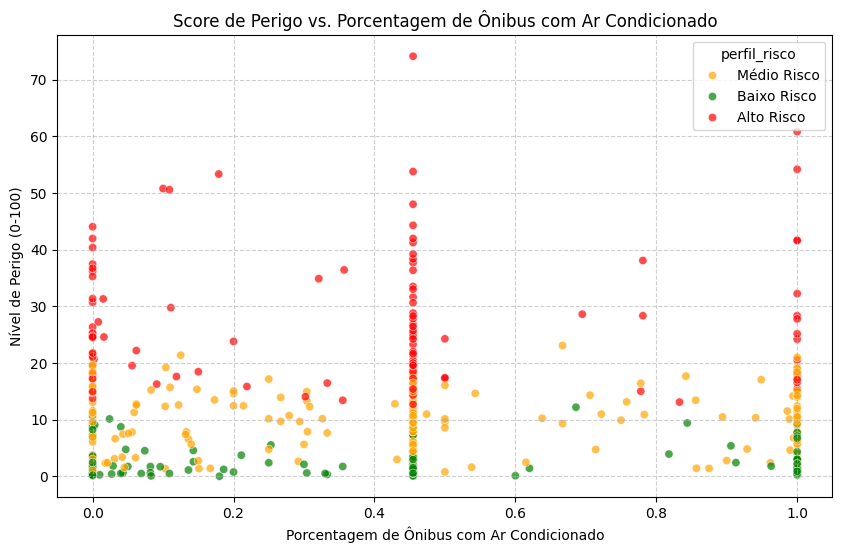

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=dataset_agregado,
    x='indicador_ar_condicionado',
    y='nivel_perigo_score',
    hue='perfil_risco',
    palette={'Alto Risco': 'red', 'Médio Risco': 'orange', 'Baixo Risco': 'green'},
    alpha=0.7
)
plt.title('Score de Perigo vs. Porcentagem de Ônibus com Ar Condicionado')
plt.xlabel('Porcentagem de Ônibus com Ar Condicionado')
plt.ylabel('Nível de Perigo (0-100)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

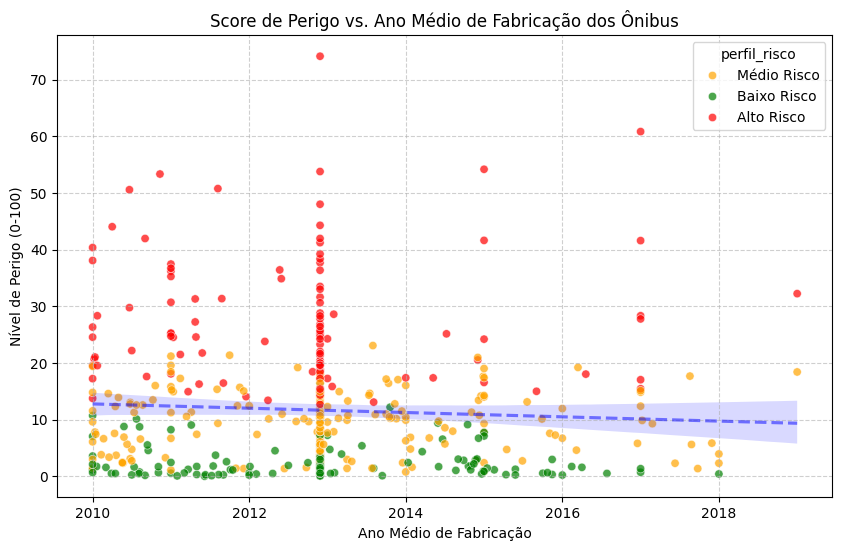

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=dataset_agregado,
    x='ano_fabricacao',
    y='nivel_perigo_score',
    hue='perfil_risco',
    palette={'Alto Risco': 'red', 'Médio Risco': 'orange', 'Baixo Risco': 'green'},
    alpha=0.7
)
sns.regplot(
    data=dataset_agregado,
    x='ano_fabricacao',
    y='nivel_perigo_score',
    scatter=False, # Não mostrar os pontos de scatter novamente
    color='blue',
    line_kws={'linestyle': '--', 'alpha': 0.5}, # Linha pontilhada
    ax=plt.gca() # Desenhar no eixo atual
)
plt.title('Score de Perigo vs. Ano Médio de Fabricação dos Ônibus')
plt.xlabel('Ano Médio de Fabricação')
plt.ylabel('Nível de Perigo (0-100)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Veja que a linha pontilhada azul (linha de regressão) indica a tendência geral da relação entre "Ano Médio de Fabricação" e "Nível de Perigo" da linha, como a linha apresenta uma inclinação negativa, pode-se concluir que quanto mais novos os ônibus, menor seu nível de perigo.

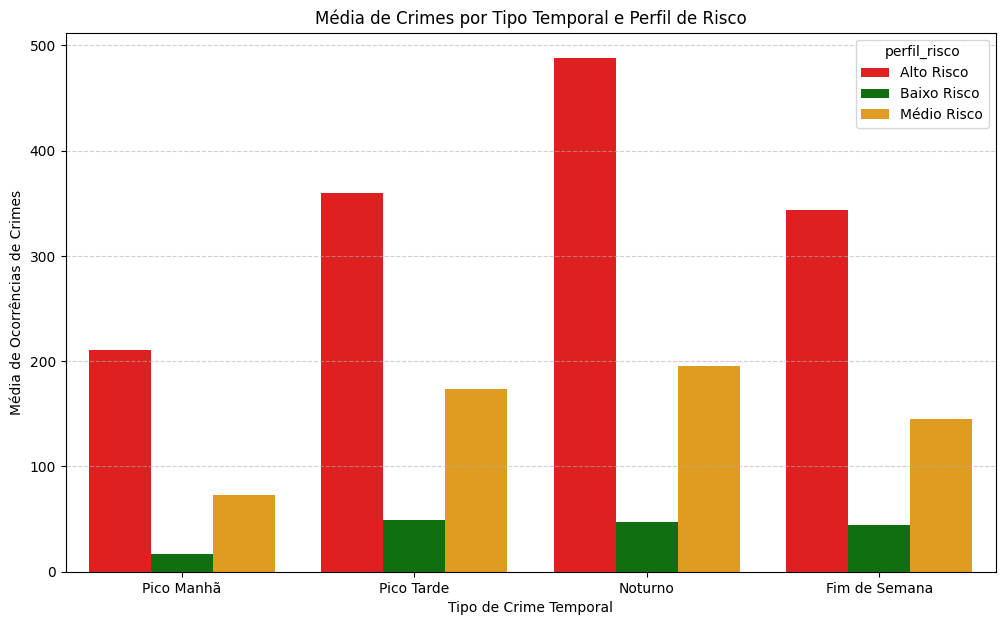

In [ ]:
# Preparando os dados para o gráfico de barras dos crimes temporais por perfil de risco
crimes_temporais = dataset_agregado.groupby('perfil_risco')[['crimes_pico_manha', 'crimes_pico_tarde', 'crimes_noturnos', 'crimes_fim_semana']].mean().reset_index()
crimes_temporais_melted = crimes_temporais.melt(
    id_vars='perfil_risco',
    var_name='Tipo de Crime Temporal',
    value_name='Média de Crimes'
)

# Mapeando para nomes mais legíveis
crimes_temporais_melted['Tipo de Crime Temporal'] = crimes_temporais_melted['Tipo de Crime Temporal'].map({
    'crimes_pico_manha': 'Pico Manhã',
    'crimes_pico_tarde': 'Pico Tarde',
    'crimes_noturnos': 'Noturno',
    'crimes_fim_semana': 'Fim de Semana'
})

plt.figure(figsize=(12, 7))
sns.barplot(
    data=crimes_temporais_melted,
    x='Tipo de Crime Temporal',
    y='Média de Crimes',
    hue='perfil_risco',
    palette={'Alto Risco': 'red', 'Médio Risco': 'orange', 'Baixo Risco': 'green'}
)
plt.title('Média de Crimes por Tipo Temporal e Perfil de Risco')
plt.xlabel('Tipo de Crime Temporal')
plt.ylabel('Média de Ocorrências de Crimes')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

### Validação Cruzada para o Modelo de Regressão (Nível de Perigo)

In [ ]:
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Definir as features (X) e o target (y) novamente com as novas colunas
features = [
    'n_paradas',
    'pct_sem_crime',
    'price',
    'crimes_dia_max',
    'crimes_dia_min',
    'crimes_dia_std',
    'crimes_hora_max',
    'crimes_hora_min',
    'crimes_hora_std',
    'indicador_ar_condicionado',
    'ano_fabricacao',
    'duracao_viagem',
    'crimes_pico_manha',
    'crimes_pico_tarde',
    'crimes_noturnos',
    'crimes_fim_semana'
]
y = dataset_agregado['crimes_total']
X = dataset_agregado[features]

# Escalar as features
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X)
X = pd.DataFrame(X_scaled, columns=X.columns)

# Configuração da Validação Cruzada
kf = KFold(n_splits=5, shuffle=True, random_state=42)

rmse_scores = []
r2_scores = []

# Executar a Validação Cruzada
for fold, (train_index, test_index) in enumerate(kf.split(X, y)):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    rmse_scores.append(rmse)
    r2_scores.append(r2)

    print(f"Fold {fold+1}: RMSE = {rmse:.2f}, R² = {r2:.2f}")

print(f"\nMédia RMSE: {np.mean(rmse_scores):.2f} (Std: {np.std(rmse_scores):.2f})")
print(f"Média R²: {np.mean(r2_scores):.2f} (Std: {np.std(r2_scores):.2f})")

Fold 1: RMSE = 1436.81, R² = 0.76
Fold 2: RMSE = 2300.67, R² = 0.58
Fold 3: RMSE = 1779.57, R² = 0.66
Fold 4: RMSE = 1986.75, R² = 0.56
Fold 5: RMSE = 1412.27, R² = 0.69

Média RMSE: 1783.21 (Std: 336.69)
Média R²: 0.65 (Std: 0.07)


Média RMSE: O RMSE (Root Mean Squared Error) médio de 1783.21 indica que, em média, a previsão do modelo de regressão para o total de crimes desvia cerca de 1783.21 unidades do valor real. A variação (Std: 336.69) mostra uma consistência razoável entre os folds.

Média R²: O R² médio de 0.65 significa que o modelo explica aproximadamente 65% da variância no total de crimes. Isso sugere que o modelo tem um poder preditivo moderado, mas ainda há uma parte significativa da variância que não é explicada pelas features atuais.

### Validação Cruzada para o Modelo de Clustering (Agrupamento de Risco)

In [ ]:
from sklearn.cluster import KMeans
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, adjusted_rand_score
import numpy as np

# Separar as features usadas para clustering
clustering_features = ['n_paradas', 'crimes_medio', 'crimes_max', 'crimes_total', 'pct_sem_crime']
X_cluster = dataset_agregado[clustering_features]

# Escalar as features para o clustering
scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)
X_cluster_scaled_df = pd.DataFrame(X_cluster_scaled, columns=clustering_features, index=X_cluster.index)

# Configuração da Validação Cruzada
kf_cluster = KFold(n_splits=5, shuffle=True, random_state=42)

silhouette_scores = []
# Vamos coletar os labels de cada fold para calcular a estabilidade usando ARI
all_fold_labels = []

# Executar a Validação Cruzada
for fold, (train_index, test_index) in enumerate(kf_cluster.split(X_cluster_scaled_df)):
    X_train_fold, X_test_fold = X_cluster_scaled_df.iloc[train_index], X_cluster_scaled_df.iloc[test_index]

    # Treinar KMeans no conjunto de treino
    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    kmeans.fit(X_train_fold)

    # Prever clusters para o conjunto de teste
    # Usamos o modelo treinado para prever os clusters nos dados de teste.
    # É importante usar os dados de teste para calcular o Silhouette Score para avaliar o quão bem
    # o modelo generaliza para dados não vistos, mantendo a integridade da validação cruzada.
    test_labels = kmeans.predict(X_test_fold)

    # Calcular Silhouette Score no conjunto de teste
    # O Silhouette Score exige que haja mais de 1 cluster e mais de 1 amostra.
    if len(np.unique(test_labels)) > 1 and len(test_labels) > 1:
        silhouette = silhouette_score(X_test_fold, test_labels)
        silhouette_scores.append(silhouette)
    else:
        silhouette_scores.append(np.nan) # Se não for possível calcular, adicione NaN

    # Para estabilidade, vamos prever em todos os dados e armazenar (com cuidado para mapeamento)
    # Uma abordagem comum para ARI é comparar as atribuições de clusters de duas execuções diferentes
    # do algoritmo de clustering ou para ver a consistência das atribuições para um mesmo ponto de dado
    # em diferentes folds.
    # Por simplicidade aqui, vamos apenas armazenar os labels dos dados de teste para uma futura análise se necessário.
    # Para ARI, seria mais robusto ter duas execuções completas do KMeans no *mesmo* dataset e comparar os labels.
    # Ou, comparar os labels de um fold com os labels de outro fold para os mesmos pontos.

    # Para este propósito, o Silhouette Score já nos dá uma boa indicação da qualidade dos clusters.
    # A estabilidade pode ser inferida pela variância do Silhouette Score entre os folds.

    print(f"Fold {fold+1}: Silhouette Score = {silhouette_scores[-1]:.2f}")

print(f"\nMédia Silhouette Score: {np.nanmean(silhouette_scores):.2f} (Std: {np.nanstd(silhouette_scores):.2f})")


Fold 1: Silhouette Score = 0.28
Fold 2: Silhouette Score = 0.27
Fold 3: Silhouette Score = 0.34
Fold 4: Silhouette Score = 0.29
Fold 5: Silhouette Score = 0.31

Média Silhouette Score: 0.30 (Std: 0.03)


Média Silhouette Score: 0.30 (Std: 0.03): O Silhouette Score médio de 0.30 indica que os clusters são razoavelmente bem separados. Um score próximo de 0 sugere clusters que estão muito próximos ou sobrepostos, enquanto um score próximo de 1 indica clusters bem distintos. Embora não seja um score muito alto, a baixa variação (Std: 0.03) entre os folds sugere que a estrutura dos clusters é consistente.

## ETAPA 1 — MAPEAMENTO DE ROTAS PARA PARADAS

### Função: `preparar_mapeamento_rotas`

Esta função cria um dicionário que associa cada `route_short_name` a um conjunto (`set`) contendo todos os `stop_id` únicos atendidos pela linha.

In [ ]:
def preparar_mapeamento_rotas(paradas_linhas):
    """
    Cria um dicionário que mapeia cada nome abreviado de rota para um conjunto de IDs de paradas.

    A função agrupa o DataFrame `paradas_linhas` por `route_short_name` e coleta todos os
    `stop_id`s únicos associados a cada rota em um conjunto (set), retornando um dicionário
    onde as chaves são os nomes abreviados das rotas e os valores são os conjuntos de IDs de paradas.

    Args:
        paradas_linhas (pd.DataFrame): DataFrame contendo as colunas 'route_short_name' e 'stop_id',
                                    representando as paradas que cada linha de ônibus atende.

    Returns:
        dict: Um dicionário onde as chaves são os `route_short_name`s e os valores são
            conjuntos (sets) de `stop_id`s únicos atendidos por essa rota.

    Exemplo:
        {
            "474": {101, 102, 103},
            "457": {200, 201, 202}
        }
    """
    # Agrupa por 'route_short_name' e coleta 'stop_id's únicos em conjuntos
    route_to_stops_map = paradas_linhas.groupby('route_short_name')['stop_id'].apply(set).to_dict()
    return route_to_stops_map

# Chamada da função com o DataFrame `paradas_linhas`
route_to_stops_map = preparar_mapeamento_rotas(paradas_linhas)

# Impressão da quantidade total de linhas processadas
print(f"Quantidade total de linhas processadas: {len(route_to_stops_map)}\n")

# Impressão de exemplo de 3 linhas do dicionário
print("Exemplo de 3 linhas do dicionário:")
for i, (route, stops) in enumerate(route_to_stops_map.items()):
    if i >= 3:
        break
    print(f"  Rota: '{route}', Paradas: {list(stops)[:5]}... (total {len(stops)} paradas)")


Quantidade total de linhas processadas: 483

Exemplo de 3 linhas do dicionário:
  Rota: '0', Paradas: ['5152O00280C0', '5144O00454C0', 'n7vj', '7q6m', '3045O00037C9']... (total 21 paradas)
  Rota: '006', Paradas: ['1161O00017C0', '1005O00172C0', '1014O00080C0', '1014O00041C0', '1014O00040C0']... (total 49 paradas)
  Rota: '007', Paradas: ['1161O00017C0', '1005O00172C0', '1005O00033S0', '1014O00080C0', '1014O00041C0']... (total 58 paradas)


## ETAPA 2 — PREPARAÇÃO DAS GEOMETRIAS DAS ROTAS

In [ ]:
from shapely.geometry import MultiLineString, LineString

def preparar_geometrias_rotas(gdf_linhas):
    """
    Cria um dicionário associando cada `route_short_name` a uma geometria representativa da rota.

    A geometria é agregada utilizando `unary_union` para combinar todas as partes de uma rota
    em uma única MultiLineString (ou LineString se houver apenas uma parte).

    Args:
        gdf_linhas (gpd.GeoDataFrame): GeoDataFrame contendo as colunas 'route_short_name'
                                      e 'geometry', onde 'geometry' representa as linhas das rotas.
                                      O CRS deve ser consistente.

    Returns:
        dict: Um dicionário onde as chaves são os `route_short_name`s e os valores são
              objetos de geometria Shapely (MultiLineString ou LineString) agregados para cada rota.

    Exemplo:
        {
            "474": MultiLineString([(lon1, lat1), (lon2, lat2), ...]),
            "457": MultiLineString([(lonA, latA), (lonB, latB), ...])
        }
    """
    # Certificar-se de que o CRS está consistente (já deve estar 'EPSG:31983' do passo anterior)
    if gdf_linhas.crs != 'EPSG:31983':
        gdf_linhas = gdf_linhas.to_crs('EPSG:31983')

    # Remover geometrias nulas antes de agrupar
    gdf_linhas = gdf_linhas.dropna(subset=['geometry'])
    gdf_linhas = gdf_linhas[~gdf_linhas.geometry.is_empty]

    # Agrupar por route_short_name e agregar as geometrias usando union_all()
    # Isso combina LineStrings em MultiLineStrings ou mantém LineString se for uma única
    rotas_geometrias = gdf_linhas.groupby('route_short_name')['geometry'].apply(lambda x: x.union_all()).to_dict()

    return rotas_geometrias

# Chamada da função com o GeoDataFrame `gdf_linhas`
rotas_geometrias_map = preparar_geometrias_rotas(gdf_linhas)

# Impressão da quantidade de geometrias criadas
print(f"Quantidade de geometrias de rotas criadas: {len(rotas_geometrias_map)}\n")

# Impressão do tipo geométrico de algumas rotas de exemplo
print("Tipo geométrico de algumas rotas de exemplo:")
for i, (route_name, geometry) in enumerate(rotas_geometrias_map.items()):
    if i >= 3:
        break
    print(f"  Rota '{route_name}': {geometry.geom_type}")

Quantidade de geometrias de rotas criadas: 482

Tipo geométrico de algumas rotas de exemplo:
  Rota '006': MultiLineString
  Rota '007': MultiLineString
  Rota '10': MultiLineString


## ETAPA 3 — NORMALIZAÇÃO DE FEATURES

Nesta etapa, criaremos uma função para normalizar as features numéricas do nosso `dataset_agregado`. A normalização é um passo importante para muitos algoritmos de Machine Learning, pois ajuda a garantir que as features contribuam igualmente para o modelo, sem que features com valores maiores dominem as com valores menores.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

def normalizar_features(dataset, colunas):
    """
    Normaliza as colunas numéricas especificadas de um DataFrame para a faixa [0, 1].

    Args:
        dataset (pd.DataFrame): O DataFrame a ser normalizado.
        colunas (list): Uma lista de nomes de colunas a serem normalizadas.

    Returns:
        tuple: Um tuple contendo:
            - pd.DataFrame: O DataFrame com as colunas especificadas normalizadas.
            - sklearn.preprocessing.MinMaxScaler: O scaler ajustado (fitado) usado para a normalização.
    """
    # Cria uma cópia do DataFrame para evitar modificar o original
    df_normalizado = dataset.copy()

    # Inicializa o MinMaxScaler
    scaler = MinMaxScaler()

    # Aplica o scaler às colunas especificadas
    # O .values é importante para que o scaler receba um array NumPy
    # e a atribuição de volta seja feita corretamente
    df_normalizado[colunas] = scaler.fit_transform(df_normalizado[colunas])

    return df_normalizado, scaler

# Exemplo de uso da função:
# Definindo as colunas numéricas a serem normalizadas do dataset_agregado
colunas_para_normalizar = [
    'n_paradas',
    'crimes_medio',
    'crimes_max',
    'crimes_total',
    'pct_sem_crime',
    'price',
    'nivel_perigo_score',
    'crimes_dia_max',
    'crimes_dia_min',
    'crimes_dia_std',
    'crimes_hora_max',
    'crimes_hora_min',
    'crimes_hora_std',
    'indicador_ar_condicionado',
    'ano_fabricacao',
    'duracao_viagem',
    'crimes_pico_manha',
    'crimes_pico_tarde',
    'crimes_noturnos',
    'crimes_fim_semana'
]

# Chamando a função de normalização
dataset_normalizado, scaler_utilizado = normalizar_features(dataset_agregado, colunas_para_normalizar)

# Exibindo as primeiras linhas do DataFrame normalizado para ver o resultado
print("DataFrame normalizado (primeiras 5 linhas):")
display(dataset_normalizado.head())

# Exibindo o scaler utilizado (pode ser útil para transformar novos dados no futuro)
print("Scaler utilizado:")
print(scaler_utilizado)

DataFrame normalizado (primeiras 5 linhas):


,route_short_name,n_paradas,crimes_medio,crimes_max,crimes_total,pct_sem_crime,price,crimes_dia_max,crimes_dia_min,crimes_dia_std,...,cluster,perfil_risco,route_id,indicador_ar_condicionado,duracao_viagem,ano_fabricacao,crimes_pico_manha,crimes_pico_tarde,crimes_noturnos,crimes_fim_semana
0,0,0.023861,0.128589,0.093023,0.002711,0.328735,0.07564,0.029877,0.004866,0.048539,...,0,Médio Risco,0,0.454803,0.371322,0.322801,0.010526,0.018759,0.022143,0.012236
1,006,0.084599,0.230489,0.232558,0.045420,0.250201,0.00000,0.126538,0.036496,0.187762,...,0,Médio Risco,O0006AAA0A,1.000000,0.170172,0.888889,0.081203,0.093795,0.107174,0.044494
2,007,0.104121,0.232915,0.232558,0.069111,0.277789,0.00000,0.126538,0.046229,0.188368,...,0,Médio Risco,O0007AAA0A,1.000000,0.202236,0.850000,0.090226,0.101010,0.118689,0.048943
3,10,0.440347,0.031136,0.046512,0.040332,0.768727,0.00000,0.082601,0.024331,0.138888,...,1,Baixo Risco,0,0.454803,0.371322,0.322801,0.003008,0.083694,0.039858,0.057842
4,100,0.236443,0.096644,0.104651,0.049842,0.283226,0.00000,0.135325,0.029197,0.217157,...,0,Médio Risco,O0100AAA0A,0.990000,0.245779,0.686667,0.087218,0.147186,0.069088,0.067853


Scaler utilizado:
MinMaxScaler()


<Axes: >

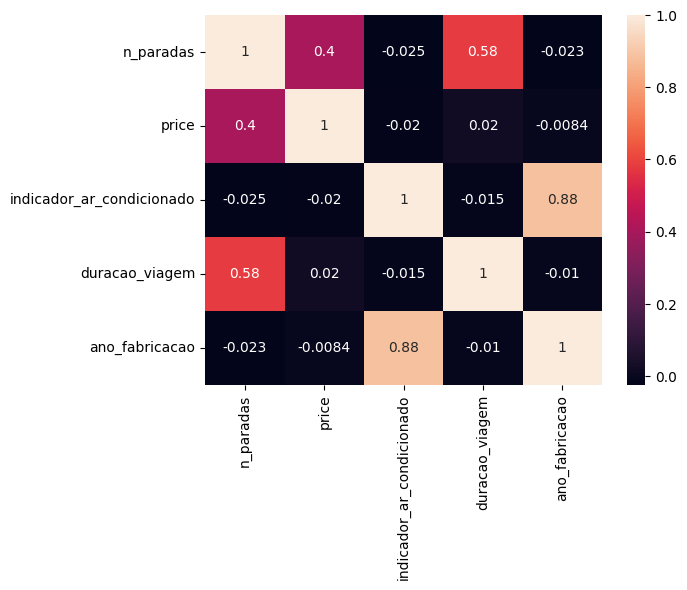

In [ ]:
import seaborn as sns
dataset_normalizado_qualidade= dataset_normalizado[['n_paradas', 'price', 'indicador_ar_condicionado', 'duracao_viagem','ano_fabricacao' ]]
sns.heatmap(dataset_normalizado_qualidade.corr(), annot=True)

## ETAPA 4 — ESTRUTURAÇÃO PARA BACKEND

Nesta etapa, vamos criar uma função para agrupar todas as estruturas de dados e mapeamentos que preparamos. Isso facilitará a integração com sistemas de backend, como FastAPI e Streamlit, garantindo que os dados estejam centralizados e prontos para o uso em um sistema de recomendação.

In [ ]:
def preparar_dados_backend(route_to_stops_map, rotas_geometrias_map, dataset_agregado_normalizado, scaler_features):
    """
    Centraliza todas as estruturas de dados preparadas para uso no backend de recomendação.

    Args:
        route_to_stops_map (dict): Dicionário mapeando 'route_short_name' para 'stop_id's.
        rotas_geometrias_map (dict): Dicionário mapeando 'route_short_name' para geometrias de rotas.
        dataset_agregado_normalizado (pd.DataFrame): DataFrame agregado e normalizado com as features das rotas.
        scaler_features (sklearn.preprocessing.MinMaxScaler): O scaler usado para normalizar as features numéricas.

    Returns:
        dict: Um dicionário contendo todas as estruturas de dados centralizadas.
    """
    backend_data = {
        "route_to_stops": route_to_stops_map,
        "route_geometries": rotas_geometrias_map,
        "dataset_agregado_normalizado": dataset_agregado_normalizado,
        "scaler_features": scaler_features
    }
    return backend_data

# Chamada da função para preparar os dados para o backend
data_for_backend = preparar_dados_backend(
    route_to_stops_map,
    rotas_geometrias_map,
    dataset_normalizado,
    scaler_utilizado
)

print("Estrutura de dados para o backend criada com sucesso!")
print(f"Chaves disponíveis: {list(data_for_backend.keys())}")


Estrutura de dados para o backend criada com sucesso!
Chaves disponíveis: ['route_to_stops', 'route_geometries', 'dataset_agregado_normalizado', 'scaler_features']


### Verificando as estruturas dentro do `data_for_backend`

In [ ]:
print("Tamanho de route_to_stops_map:", len(data_for_backend['route_to_stops']))
print("Tamanho de rotas_geometrias_map:", len(data_for_backend['route_geometries']))
print("Shape de dataset_agregado_normalizado:", data_for_backend['dataset_agregado_normalizado'].shape)
print("Tipo do scaler_features:", type(data_for_backend['scaler_features']))

Tamanho de route_to_stops_map: 483
Tamanho de rotas_geometrias_map: 482
Shape de dataset_agregado_normalizado: (483, 24)
Tipo do scaler_features: <class 'sklearn.preprocessing._data.MinMaxScaler'>


## ETAPA 5 — SIMILARIDADE ENTRE LINHAS

In [ ]:
def calcular_similaridade_paradas(stops_a, stops_b):
    """
    Calcula a similaridade de Jaccard entre dois conjuntos de IDs de paradas.

    A similaridade de Jaccard é uma medida da sobreposição de dois conjuntos,
    definida como o tamanho da intersecção dos conjuntos dividido pelo tamanho
    da união dos conjuntos.

    Args:
        stops_a (set): Um conjunto de IDs de paradas da primeira rota.
        stops_b (set): Um conjunto de IDs de paradas da segunda rota.

    Returns:
        float: Um valor entre 0 e 1, representando a similaridade de Jaccard.
               Retorna 0.0 se a união dos conjuntos for vazia (para evitar divisão por zero).
    """
    # Calcula a intersecção dos dois conjuntos de paradas
    intersecao = len(stops_a.intersection(stops_b))
    # Calcula a união dos dois conjuntos de paradas
    uniao = len(stops_a.union(stops_b))

    # Evita divisão por zero: se a união for 0, não há paradas em nenhum dos conjuntos,
    # então a similaridade é 0.
    if uniao == 0:
        return 0.0

    # Calcula a similaridade de Jaccard
    jaccard_similarity = intersecao / uniao
    return jaccard_similarity

# Exemplo de uso da função
# Obtendo um exemplo de conjuntos de paradas para duas rotas do nosso mapeamento
route_to_stops_map = data_for_backend['route_to_stops']

# Escolher duas rotas para demonstração (por exemplo, as primeiras duas do dicionário)
route_names = list(route_to_stops_map.keys())
if len(route_names) >= 2:
    rota_exemplo_a = route_names[0]
    rota_exemplo_b = route_names[1]

    paradas_rota_a = route_to_stops_map[rota_exemplo_a]
    paradas_rota_b = route_to_stops_map[rota_exemplo_b]

    similaridade = calcular_similaridade_paradas(paradas_rota_a, paradas_rota_b)
    print(f"Similaridade de Jaccard entre a rota '{rota_exemplo_a}' e a rota '{rota_exemplo_b}': {similaridade:.4f}")
else:
    print("Não há rotas suficientes no mapeamento para demonstrar a similaridade.")


Similaridade de Jaccard entre a rota '0' e a rota '006': 0.0000


## ETAPA 6 — SUGESTÃO DE LINHAS ALTERNATIVAS

Nesta etapa, implementaremos uma função para sugerir linhas de ônibus alternativas com base na similaridade de Jaccard de suas paradas. Essa função será fundamental para o sistema de recomendação, permitindo encontrar rotas substitutas que atendam a pontos de interesse semelhantes.

In [ ]:
def sugerir_linhas_alternativas(
    linha_alvo,
    route_to_stops,
    top_n=5
):
    """
    Sugere linhas de ônibus alternativas funcionalmente similares à linha alvo
    com base na sobreposição de paradas.

    Args:
        linha_alvo (str): O `route_short_name` da linha de ônibus para a qual
                          se deseja encontrar alternativas.
        route_to_stops (dict): Um dicionário onde as chaves são `route_short_name`s
                               e os valores são conjuntos (sets) de `stop_id`s únicos
                               atendidos por essa rota.
        top_n (int, optional): O número máximo de sugestões a serem retornadas.
                               Padrão é 5.

    Returns:
        list: Uma lista de dicionários, onde cada dicionário representa uma linha
              alternativa e contém seu `route_short_name` e a `similaridade`
              de Jaccard com a linha alvo, ordenada de forma decrescente.

    Exemplo da saída:
        [
            {
                "linha": "472",
                "similaridade": 0.81
            },
            ...
        ]
    """
    # 1. Obter conjunto de paradas da linha alvo
    paradas_alvo = route_to_stops.get(linha_alvo)

    if paradas_alvo is None:
        print(f"Erro: Linha alvo '{linha_alvo}' não encontrada no mapeamento de paradas.")
        return []

    alternativas = []

    # 2. Iterar por todas as outras linhas
    for outra_linha, paradas_outra_linha in route_to_stops.items():
        # 3. Ignorar a própria linha alvo
        if outra_linha == linha_alvo:
            continue

        # 4. Calcular similaridade de Jaccard
        similaridade = calcular_similaridade_paradas(paradas_alvo, paradas_outra_linha)

        # 5. Armazenar resultados
        if similaridade > 0:  # Apenas rotas com alguma similaridade
            alternativas.append({
                "linha": outra_linha,
                "similaridade": similaridade
            })

    # 6. Ordenar por similaridade (decrescente)
    alternativas_ordenadas = sorted(alternativas,
                                  key=lambda x: x['similaridade'],
                                  reverse=True)

    # 7. Retornar as melhores alternativas (top_n)
    return alternativas_ordenadas[:top_n]

# Exemplo de uso da função:
print("\n--- Demonstração da função sugerir_linhas_alternativas ---")

# Escolha uma linha de exemplo que exista no seu dataset
sample_route = '232' # Substitua por uma route_short_name existente se '232' não for ideal

# Gerar sugestões de linhas alternativas
sugestoes = sugerir_linhas_alternativas(
    sample_route,
    data_for_backend['route_to_stops'],
    top_n=10  # Exemplo: pedir as 10 melhores alternativas
)

print(f"Top 10 alternativas para a linha '{sample_route}':")
if sugestoes:
    for sug in sugestoes:
        print(f"  - Linha: {sug['linha']}, Similaridade de Jaccard: {sug['similaridade']:.4f}")
else:
    print(f"  Nenhuma alternativa encontrada para a linha '{sample_route}'.")


--- Demonstração da função sugerir_linhas_alternativas ---
Top 10 alternativas para a linha '232':
  - Linha: SN232, Similaridade de Jaccard: 1.0000
  - Linha: 2114, Similaridade de Jaccard: 0.4876
  - Linha: 2110, Similaridade de Jaccard: 0.4434
  - Linha: 341, Similaridade de Jaccard: 0.4034
  - Linha: 2111, Similaridade de Jaccard: 0.3858
  - Linha: 306, Similaridade de Jaccard: 0.3858
  - Linha: 390, Similaridade de Jaccard: 0.3730
  - Linha: 2114TP, Similaridade de Jaccard: 0.3476
  - Linha: 368, Similaridade de Jaccard: 0.3298
  - Linha: 422, Similaridade de Jaccard: 0.3242


## ETAPA 7 — SCORE MULTICRITÉRIO DAS LINHAS

### Funções para Scores Individuais

Vamos criar funções separadas para calcular scores para segurança, conforto, preço e eficiência, utilizando as features já normalizadas do `dataset_agregado_normalizado`. Os scores serão convertidos para uma escala de 0 a 100 para facilitar a interpretação.

In [ ]:
def calcular_score_seguranca(linha_info):
    """
    Calcula o score de segurança da linha (0-100).
    Critérios: crimes_total (quanto menor, mais seguro), crimes_medio (quanto menor, mais seguro),
               pct_sem_crime (quanto maior, mais seguro).
    Os inputs devem ser valores normalizados entre 0 e 1.
    """
    # Invertemos os scores de crimes para que valores menores de crime resultem em scores maiores de segurança
    # pct_sem_crime já é um indicador positivo de segurança
    score_crimes_total = (1 - linha_info['crimes_total']) * 100
    score_crimes_medio = (1 - linha_info['crimes_medio']) * 100
    score_pct_sem_crime = linha_info['pct_sem_crime'] * 100

    # Média ponderada simples, pode ser ajustado com pesos
    # Vamos dar um peso maior para a porcentagem de paradas sem crime
    score = (score_crimes_total * 0.3 + score_crimes_medio * 0.3 + score_pct_sem_crime * 0.4)
    return round(score, 2)

def calcular_score_conforto(linha_info):
    """
    Calcula o score de conforto da linha (0-100).
    Critérios: indicador_ar_condicionado (quanto maior, mais confortável),
               ano_fabricacao (quanto maior, mais novo e confortável).
    Os inputs devem ser valores normalizados entre 0 e 1.
    """
    # Ambos os indicadores já são proporcionais ao conforto
    score_ar_condicionado = linha_info['indicador_ar_condicionado'] * 100
    score_ano_fabricacao = linha_info['ano_fabricacao'] * 100

    # Média ponderada simples
    score = (score_ar_condicionado * 0.6 + score_ano_fabricacao * 0.4)
    return round(score, 2)

def calcular_score_preco(linha_info):
    """
    Calcula o score de preço da linha (0-100).
    Critérios: price (quanto menor, melhor o score para um usuário econômico).
    O input deve ser um valor normalizado entre 0 e 1.
    """
    # Invertemos o score do preço para que preços menores resultem em scores maiores
    score = (1 - linha_info['price']) * 100
    return round(score, 2)

def calcular_score_eficiencia(linha_info):
    """
    Calcula o score de eficiência da linha (0-100).
    Critérios: duracao_viagem (quanto menor, mais eficiente).
    O input deve ser um valor normalizado entre 0 e 1.
    """
    # Invertemos o score da duração da viagem para que tempos menores resultem em scores maiores
    score = (1 - linha_info['duracao_viagem']) * 100
    return round(score, 2)

### Função Principal: Score Multicritério da Rota

Esta função combina os scores individuais de segurança, conforto, preço e eficiência, utilizando pesos configuráveis para adaptar o score final a diferentes perfis de usuário.

In [ ]:
def calcular_score_final(linha_info, pesos):
    """
    Calcula o score final multicritério de uma linha de ônibus.

    Args:
        linha_info (pd.Series): Uma linha do dataset normalizado contendo as informações da rota.
                                 Deve incluir as features necessárias para os scores individuais.
        pesos (dict): Um dicionário com os pesos para cada critério (S=Segurança, C=Conforto, E=Eficiência, P=Preço).
                      Os pesos devem somar 1 ou serão normalizados internamente.

    Returns:
        float: O score final da rota, entre 0 e 100.
    """
    # Normaliza os pesos para garantir que somem 1
    soma_pesos = sum(pesos.values())
    pesos_normalizados = {k: v / soma_pesos for k, v in pesos.items()}

    # Calcula os scores individuais usando as funções auxiliares
    score_seguranca = calcular_score_seguranca(linha_info)
    score_conforto = calcular_score_conforto(linha_info)
    score_eficiencia = calcular_score_eficiencia(linha_info)
    score_preco = calcular_score_preco(linha_info)

    # Combina os scores com os pesos normalizados
    score_final = (
        pesos_normalizados.get('S', 0) * score_seguranca +
        pesos_normalizados.get('C', 0) * score_conforto +
        pesos_normalizados.get('E', 0) * score_eficiencia +
        pesos_normalizados.get('P', 0) * score_preco
    )

    return round(score_final, 2)

# Exemplo de Perfis de Usuário
perfis_usuario = {
    'economico': {'S': 0.1, 'C': 0.1, 'E': 0.3, 'P': 0.5},  # Prioriza preço e eficiência
    'seguranca': {'S': 0.6, 'C': 0.2, 'E': 0.1, 'P': 0.1},  # Prioriza segurança
    'conforto': {'S': 0.1, 'C': 0.6, 'E': 0.2, 'P': 0.1},   # Prioriza conforto
    'balanceado': {'S': 0.25, 'C': 0.25, 'E': 0.25, 'P': 0.25} # Pesos iguais
}

### Demonstração do Cálculo do Score Final

Vamos calcular o score final para algumas linhas de ônibus utilizando diferentes perfis de usuário.

In [ ]:
# Selecionar uma linha de exemplo do dataset normalizado
# Pegaremos a primeira linha como exemplo
linha_exemplo = data_for_backend['dataset_agregado_normalizado'].iloc[0]

# Calcular o score final para o perfil 'seguranca'
score_seguranca = calcular_score_final(linha_exemplo, perfis_usuario['seguranca'])
print(f"Score final da linha '{linha_exemplo['route_short_name']}' (Perfil Segurança): {score_seguranca}")

# Calcular o score final para o perfil 'economico'
score_economico = calcular_score_final(linha_exemplo, perfis_usuario['economico'])
print(f"Score final da linha '{linha_exemplo['route_short_name']}' (Perfil Econômico): {score_economico}")

# Calcular o score final para o perfil 'balanceado'
score_balanceado = calcular_score_final(linha_exemplo, perfis_usuario['balanceado'])
print(f"Score final da linha '{linha_exemplo['route_short_name']}' (Perfil Balanceado): {score_balanceado}")

# Adicionar uma coluna de score final balanceado ao dataset_agregado
# Isso será útil para a recomendação.

dataset_normalizado['score_final_balanceado'] = dataset_normalizado.apply(
    lambda row: calcular_score_final(row, perfis_usuario['balanceado']), axis=1
)

print("\nDataset normalizado com 'score_final_balanceado':")
display(dataset_normalizado[['route_short_name', 'score_final_balanceado', 'perfil_risco']])

Score final da linha '0' (Perfil Segurança): 65.1
Score final da linha '0' (Perfil Econômico): 76.02
Score final da linha '0' (Perfil Balanceado): 66.18

Dataset normalizado com 'score_final_balanceado':


,route_short_name,score_final_balanceado,perfil_risco
0,0,66.18,Médio Risco
1,006,85.07,Médio Risco
2,007,83.96,Médio Risco
3,10,72.92,Baixo Risco
4,100,82.31,Médio Risco
...,...,...,...
478,SV917,70.46,Alto Risco
479,SV921,87.07,Baixo Risco
480,SV922,72.87,Baixo Risco
481,SVB665,49.77,Alto Risco


## ETAPA 8 — RECOMENDAÇÃO FINAL

### Função `recomendar_melhor_rota`

Esta função é o coração do sistema de recomendação. Ela busca as melhores alternativas para uma linha de ônibus específica, balanceando a similaridade operacional (quão parecido o trajeto é) com a qualidade da linha (segurança, conforto, preço e eficiência), adaptando-se às prioridades do usuário.

In [ ]:
def recomendar_melhor_rota(
    linha_alvo,
    dataset_agregado,
    route_to_stops,
    top_n=5,
    pesos_usuario=perfis_usuario['balanceado'] # Define um perfil balanceado como padrão
):
    """
    Recomenda as melhores alternativas para uma linha de ônibus, balanceando similaridade
    operacional e qualidade da linha, conforme as preferências do usuário.

    Args:
        linha_alvo (str): O `route_short_name` da linha de ônibus para a qual
                          se deseja encontrar alternativas.
        dataset_agregado (pd.DataFrame): DataFrame agregado e normalizado com as features das rotas.
                                       Espera-se que este seja o `dataset_normalizado`.
        route_to_stops (dict): Dicionário mapeando 'route_short_name' para um conjunto de 'stop_id's.
        top_n (int, optional): O número máximo de opções a serem retornadas.
        pesos_usuario (dict): Dicionário com os pesos para cada critério (S=Segurança, C=Conforto, E=Eficiência, P=Preço).
                              Os pesos devem somar 1 ou serão normalizados internamente.

    Returns:
        dict: Um dicionário contendo a linha original, a melhor alternativa e outras opções,
              no formato especificado.

    Fluxo:
    1.  **Encontrar linhas similares:** Utiliza a similaridade de Jaccard entre os conjuntos de paradas.
    2.  **Calcular score de qualidade:** Avalia cada alternativa usando o score multicritério, considerando
        segurança, conforto, preço e eficiência, de acordo com os `pesos_usuario`.
    3.  **Ranqueamento:** Combina a similaridade de Jaccard e o score de qualidade para criar um
        `combined_score`, que é usado para ordenar as alternativas.
    4.  **Retornar melhores opções:** Estrutura o resultado no formato esperado.
    """

    # 1. Encontrar linhas similares (reutilizando sugerir_linhas_alternativas)
    alternativas_jaccard = sugerir_linhas_alternativas(
        linha_alvo,
        route_to_stops,
        top_n=None # Não limitar aqui, para calcular o score de todas
    )

    # Estrutura de retorno padrão para caso de erro ou nenhuma alternativa
    resultado_vazio = {
        "linha_original": linha_alvo,
        "melhor_alternativa": None,
        "outras_opcoes": []
    }

    if not alternativas_jaccard:
        print(f"Nenhuma alternativa funcional encontrada para a linha '{linha_alvo}'.")
        return resultado_vazio

    # Lista para armazenar todas as alternativas avaliadas
    evaluated_alternatives = []

    for alt in alternativas_jaccard:
        alt_route_short_name = alt['linha']
        jaccard_similarity = alt['similaridade']

        # Obter informações normalizadas da linha alternativa
        # Usamos .copy() para evitar SettingWithCopyWarning se houver manipulações futuras
        linha_info = dataset_agregado[
            dataset_agregado['route_short_name'] == alt_route_short_name
        ]

        if not linha_info.empty:
            linha_info = linha_info.iloc[0]
            # 2. Calcular score de qualidade usando os pesos do usuário
            score_qualidade = calcular_score_final(linha_info, pesos_usuario)

            # Balanceamento: Combinando similaridade e score de qualidade para ranking
            # Uma abordagem simples é um score combinado (ex: 50% similaridade, 50% qualidade).
            # O score de qualidade já está entre 0-100, a similaridade entre 0-1.
            # Normalizamos o score de qualidade para 0-1 antes de combinar.
            combined_score = (jaccard_similarity * 0.5) + (score_qualidade / 100 * 0.5)

            evaluated_alternatives.append({
                "linha": alt_route_short_name,
                "similaridade": round(jaccard_similarity, 4),
                "score_qualidade": round(score_qualidade, 2),
                "perfil_risco": linha_info['perfil_risco'], # Adicionar perfil de risco para contexto
                "combined_score": round(combined_score, 4)
            })

    if not evaluated_alternatives:
        print(f"Nenhuma alternativa avaliada com sucesso para a linha '{linha_alvo}'.")
        return resultado_vazio

    # 3. Ranqueamento das alternativas (por combined_score, decrescente)
    ranked_alternatives = sorted(
        evaluated_alternatives,
        key=lambda x: x['combined_score'],
        reverse=True
    )

    # 4. Retornar melhores opções no formato esperado
    melhor_alternativa = None
    outras_opcoes = []

    if ranked_alternatives:
        melhor_alternativa = {
            "linha": ranked_alternatives[0]['linha'],
            "similaridade": ranked_alternatives[0]['similaridade'],
            "score_qualidade": ranked_alternatives[0]['score_qualidade'],
            "perfil_risco": ranked_alternatives[0]['perfil_risco']
        }
        # Top N excluindo a melhor alternativa
        for alt in ranked_alternatives[1:top_n]:
            outras_opcoes.append({
                "linha": alt['linha'],
                "similaridade": alt['similaridade'],
                "score_qualidade": alt['score_qualidade'],
                "perfil_risco": alt['perfil_risco']
            })

    return {
        "linha_original": linha_alvo,
        "melhor_alternativa": melhor_alternativa,
        "outras_opcoes": outras_opcoes
    }

# --- Demonstração da Função ---
print("\n--- Demonstração da função recomendar_melhor_rota ---")

# Exemplo 1: Recomendar para a linha '232' (Perfil Balanceado Padrão)
alternativas_232_balanceado = recomendar_melhor_rota(
    linha_alvo='232',
    dataset_agregado=data_for_backend['dataset_agregado_normalizado'],
    route_to_stops=data_for_backend['route_to_stops'],
    top_n=5
)

print(f"\nRecomendações para a linha '232' (Perfil Balanceado):")
print(alternativas_232_balanceado)

# Exemplo 2: Recomendar para a linha '232' (Priorizando Segurança)
alternativas_232_seguranca = recomendar_melhor_rota(
    linha_alvo='232',
    dataset_agregado=data_for_backend['dataset_agregado_normalizado'],
    route_to_stops=data_for_backend['route_to_stops'],
    top_n=5,
    pesos_usuario=perfis_usuario['seguranca']
)

print(f"\nRecomendações para a linha '232' (Priorizando Segurança):")
print(alternativas_232_seguranca)

# Exemplo 3: Recomendar para uma linha com baixo risco (e perfil balanceado)
alternativas_10_balanceado = recomendar_melhor_rota(
    linha_alvo='10',
    dataset_agregado=data_for_backend['dataset_agregado_normalizado'],
    route_to_stops=data_for_backend['route_to_stops'],
    top_n=5
)
print(f"\nRecomendações para a linha '10' (Perfil Balanceado):")
print(alternativas_10_balanceado)


--- Demonstração da função recomendar_melhor_rota ---

Recomendações para a linha '232' (Perfil Balanceado):
{'linha_original': '232', 'melhor_alternativa': {'linha': 'SN232', 'similaridade': 1.0, 'score_qualidade': np.float64(65.59), 'perfil_risco': 'Médio Risco'}, 'outras_opcoes': [{'linha': '202', 'similaridade': 0.2896, 'score_qualidade': np.float64(81.91), 'perfil_risco': 'Médio Risco'}, {'linha': '217', 'similaridade': 0.239, 'score_qualidade': np.float64(83.79), 'perfil_risco': 'Médio Risco'}, {'linha': '210', 'similaridade': 0.2549, 'score_qualidade': np.float64(81.74), 'perfil_risco': 'Médio Risco'}, {'linha': '247', 'similaridade': 0.2731, 'score_qualidade': np.float64(79.05), 'perfil_risco': 'Médio Risco'}]}

Recomendações para a linha '232' (Priorizando Segurança):
{'linha_original': '232', 'melhor_alternativa': {'linha': 'SN232', 'similaridade': 1.0, 'score_qualidade': np.float64(59.89), 'perfil_risco': 'Médio Risco'}, 'outras_opcoes': [{'linha': '202', 'similaridade': 0.

## ETAPA 9 — EXPLICABILIDADE

Nesta etapa, criaremos uma função para gerar justificativas textuais claras e interpretáveis para as recomendações de linhas de ônibus. A função irá analisar as características normalizadas da linha recomendada e, com base em thresholds simples, descreverá os principais pontos fortes que levaram à sua sugestão.

In [ ]:
def explicar_recomendacao(info_linha):
    """
    Gera justificativas textuais para a recomendação de uma linha de ônibus,
    com base nas suas características normalizadas.

    Args:
        info_linha (pd.Series): Uma linha do dataset normalizado contendo as informações da rota.

    Returns:
        list: Uma lista de strings, onde cada string é uma explicação para a recomendação.
    """
    explanations = []

    # Thresholds (valores normalizados entre 0 e 1)
    THRESHOLD_LOW_CRIME = 0.2
    THRESHOLD_HIGH_PCT_NO_CRIME = 0.8
    THRESHOLD_HIGH_AC = 0.7
    THRESHOLD_MODERN_YEAR = 0.7
    THRESHOLD_EFFICIENT_DURATION = 0.2
    THRESHOLD_COMPETITIVE_PRICE = 0.3

    # Segurança
    if info_linha['crimes_total'] < THRESHOLD_LOW_CRIME:
        explanations.append("- Possui baixa incidência criminal geral.")
    if info_linha['crimes_medio'] < THRESHOLD_LOW_CRIME:
        explanations.append("- Tem poucas ocorrências de crimes por parada.")
    if info_linha['pct_sem_crime'] > THRESHOLD_HIGH_PCT_NO_CRIME:
        explanations.append("- Grande porcentagem de paradas sem crimes registrados.")

    # Conforto
    if info_linha['indicador_ar_condicionado'] > THRESHOLD_HIGH_AC:
        explanations.append("- Alta presença de ônibus com ar condicionado.")
    if info_linha['ano_fabricacao'] > THRESHOLD_MODERN_YEAR:
        explanations.append("- Frota de ônibus mais moderna.")

    # Eficiência
    if info_linha['duracao_viagem'] < THRESHOLD_EFFICIENT_DURATION:
        explanations.append("- Viagens mais eficientes (menor duração média).")

    # Preço
    if info_linha['price'] < THRESHOLD_COMPETITIVE_PRICE:
        explanations.append("- Tarifa competitiva.")

    if not explanations:
        explanations.append("Não foi possível identificar justificativas específicas com os critérios atuais.")

    return explanations

# --- Demonstração da Função ---
print("\n--- Demonstração da função explicar_recomendacao ---")

# Exemplo: Usar a melhor alternativa encontrada anteriormente para a linha '232' (Perfil Balanceado)
alternativas_232_balanceado = recomendar_melhor_rota(
    linha_alvo='232',
    dataset_agregado=data_for_backend['dataset_agregado_normalizado'],
    route_to_stops=data_for_backend['route_to_stops'],
    top_n=5
)

if alternativas_232_balanceado['melhor_alternativa']:
    melhor_alternativa_nome = alternativas_232_balanceado['melhor_alternativa']['linha']
    linha_info_melhor_alternativa = data_for_backend['dataset_agregado_normalizado'][
        data_for_backend['dataset_agregado_normalizado']['route_short_name'] == melhor_alternativa_nome
    ].iloc[0]

    explicacoes = explicar_recomendacao(linha_info_melhor_alternativa)

    print(f"\nJustificativa para a melhor alternativa ('{melhor_alternativa_nome}') da linha '232':")
    for exp in explicacoes:
        print(exp)
else:
    print("Nenhuma melhor alternativa encontrada para a linha '232' para gerar explicações.")



--- Demonstração da função explicar_recomendacao ---

Justificativa para a melhor alternativa ('SN232') da linha '232':
- Possui baixa incidência criminal geral.
- Tarifa competitiva.


### Lógica de Decisão e Balanceamento

O sistema de recomendação `recomendar_melhor_rota` foi projetado para oferecer alternativas mais adequadas a uma linha de ônibus original, considerando diversos fatores críticos para a experiência do usuário. A decisão sobre qual linha é a 'melhor alternativa' é balanceada por:

1.  **Similaridade de Trajeto (Similaridade de Jaccard):**
    *   **Como funciona:** A função primeiro identifica linhas que compartilham um número significativo de paradas com a linha original. Isso garante que a alternativa seja funcionalmente parecida, ou seja, atenda a pontos de interesse semelhantes ao usuário. A similaridade de Jaccard mede a sobreposição entre os conjuntos de paradas. Quanto maior o valor (próximo de 1), mais paradas as duas linhas têm em comum.
    *   **Importância:** Sem uma similaridade mínima, a alternativa pode não ser útil para o propósito de viagem do usuário, mesmo que sua qualidade seja alta.

2.  **Qualidade da Linha (Score Multicritério):**
    *   **Como funciona:** Para cada linha similar encontrada, é calculado um `score_qualidade` (entre 0 e 100). Este score é uma combinação ponderada de quatro critérios principais:
        *   **Segurança (S):** Baseia-se no total de crimes, média de crimes por parada e percentual de paradas sem crime. Linhas com menos crimes e mais paradas seguras recebem scores de segurança mais altos.
        *   **Conforto (C):** Considera o indicador de ar condicionado (percentual de ônibus com AC) e o ano médio de fabricação da frota. Ônibus mais novos e com ar condicionado resultam em maior conforto.
        *   **Eficiência (E):** Avalia a duração média da viagem. Viagens mais curtas são consideradas mais eficientes e, portanto, recebem scores mais altos.
        *   **Preço (P):** Reflete o custo da passagem. Linhas com passagens mais baratas recebem scores de preço mais altos para perfis econômicos.
    *   **Importância:** A qualidade da linha é fundamental para a satisfação do usuário. A capacidade de ajustar os pesos para esses critérios (`pesos_usuario`) permite personalizar a recomendação de acordo com as preferências individuais (ex: um usuário pode priorizar segurança, outro o menor preço).

3.  **Balanceamento e Ranking:**
    *   Para determinar a 'melhor combinação', o sistema calcula um `combined_score` para cada alternativa. Este score é uma média ponderada da `similaridade de Jaccard` e do `score_qualidade`. Atualmente, ambos os componentes contribuem com 50% para o score combinado, mas esses pesos podem ser ajustados para dar mais importância à similaridade ou à qualidade, dependendo do contexto.
    *   As linhas são então ranqueadas em ordem decrescente do `combined_score`. A linha com o maior `combined_score` é apresentada como a `melhor_alternativa`, e as próximas opções são listadas em `outras_opcoes`.

### Por que uma linha pode ser considerada melhor alternativa?

Uma linha é considerada uma 'melhor alternativa' se ela:

*   **Mantém a funcionalidade:** Possui um trajeto significativamente similar à linha original, atendendo a muitas das mesmas paradas ou regiões (alta `similaridade de Jaccard`).
*   **Oferece maior qualidade:** Apresenta um `score_qualidade` superior, o que pode significar que é mais segura, mais confortável, mais econômica ou mais eficiente, dependendo do perfil de preferência configurado pelo usuário.
*   **Melhor combinação:** Seu `combined_score` é o mais alto, indicando o melhor equilíbrio entre similaridade e qualidade.

Este sistema permite que um usuário que atualmente utiliza uma linha de alto risco (mas funcional) possa encontrar uma alternativa que o leve aos mesmos lugares, mas com um perfil de risco reduzido ou maior conforto, por exemplo. A flexibilidade nos pesos (`pesos_usuario`) garante que a recomendação seja sempre relevante às necessidades e prioridades de quem a está consultando.

### Interação com o Usuário

In [ ]:
# =========================================================
# SISTEMA INTERATIVO DE RECOMENDAÇÃO DE ÔNIBUS
# PROJETO ANALYTICA
# =========================================================

# ---------------------------------------------------------
# PERFIS DISPONÍVEIS
# ---------------------------------------------------------
perfis_usuario = {
    'economico': {
        'descricao': 'Prioriza preço baixo e eficiência',
        'pesos': {'S': 0.1, 'C': 0.1, 'E': 0.3, 'P': 0.5}
    },

    'seguranca': {
        'descricao': 'Prioriza segurança da rota',
        'pesos': {'S': 0.6, 'C': 0.2, 'E': 0.1, 'P': 0.1}
    },

    'conforto': {
        'descricao': 'Prioriza conforto da viagem',
        'pesos': {'S': 0.1, 'C': 0.6, 'E': 0.2, 'P': 0.1}
    },

    'balanceado': {
        'descricao': 'Equilíbrio entre todos os critérios',
        'pesos': {'S': 0.25, 'C': 0.25, 'E': 0.25, 'P': 0.25}
    }
}


# =========================================================
# FUNÇÃO PRINCIPAL
# =========================================================
def sistema_recomendacao_terminal(data_for_backend):

    dataset = data_for_backend['dataset_agregado_normalizado']
    route_to_stops = data_for_backend['route_to_stops']

    print('=' * 60)
    print('        SISTEMA DE RECOMENDAÇÃO DE ÔNIBUS')
    print('=' * 60)

    # -----------------------------------------------------
    # ESCOLHA DO PERFIL
    # -----------------------------------------------------
    print('\nPERFIS DISPONÍVEIS:\n')

    nomes_perfis = list(perfis_usuario.keys())

    for i, perfil in enumerate(nomes_perfis, start=1):

        print(f'{i}. {perfil.upper()}')
        print(f'   -> {perfis_usuario[perfil]["descricao"]}\n')

    while True:

        try:
            opcao = int(input('Escolha o número do perfil desejado: '))

            if 1 <= opcao <= len(nomes_perfis):

                perfil_escolhido = nomes_perfis[opcao - 1]
                break

            else:
                print('Opção inválida.')

        except ValueError:
            print('Digite apenas números.')

    pesos_usuario = perfis_usuario[perfil_escolhido]['pesos']

    print(f'\nPerfil selecionado: {perfil_escolhido.upper()}')

    # -----------------------------------------------------
    # ESCOLHA DA LINHA
    # -----------------------------------------------------
    linhas_disponiveis = sorted(
        dataset['route_short_name'].astype(str).unique()
    )

    while True:

        linha_usuario = input('\nDigite a linha desejada: ').strip()

        if linha_usuario in linhas_disponiveis:
            break

        else:
            print('\nLinha não encontrada.')
            print('Exemplos disponíveis:')
            print(linhas_disponiveis[:20])

    print('\nBuscando recomendações...')

    # =====================================================
    # INFORMAÇÕES DA LINHA ORIGINAL
    # =====================================================
    info_original = dataset[
        dataset['route_short_name'].astype(str) == linha_usuario
    ].iloc[0]

    print('\n' + '=' * 60)
    print(f'INFORMAÇÕES DA LINHA ORIGINAL ({linha_usuario})')
    print('=' * 60)

    if 'total_crimes' in info_original:
        print(f"Total de crimes: {info_original['total_crimes']}")

    if 'crime_por_parada' in info_original:
        print(f"Crimes por parada: {info_original['crime_por_parada']:.2f}")

    if 'score_qualidade' in info_original:
        print(f"Score de qualidade: {info_original['score_qualidade']:.2f}/100")

    if 'perfil_risco' in info_original:
        print(f"Perfil de risco: {info_original['perfil_risco']}")

    # -----------------------------------------------------
    # JUSTIFICATIVAS DA LINHA ORIGINAL
    # -----------------------------------------------------
    print('\nJUSTIFICATIVAS DA LINHA ORIGINAL:\n')

    try:

        explicacoes_original = explicar_recomendacao(info_original)

        for exp in explicacoes_original:
            print(f'- {exp}')

    except:
        print('Não foi possível gerar justificativas.')

    # =====================================================
    # GERA RECOMENDAÇÕES
    # =====================================================
    resultado = recomendar_melhor_rota(
        linha_alvo=linha_usuario,
        dataset_agregado=dataset,
        route_to_stops=route_to_stops,
        top_n=5,
        pesos_usuario=pesos_usuario
    )

    # =====================================================
    # EXIBE RECOMENDAÇÃO
    # =====================================================
    print('\n' + '=' * 60)
    print('RECOMENDAÇÃO')
    print('=' * 60)

    if resultado['melhor_alternativa'] is None:

        print('\nNenhuma alternativa encontrada.')
        return

    melhor = resultado['melhor_alternativa']

    print('\nMELHOR ALTERNATIVA:\n')

    print(f"Linha sugerida: {melhor['linha']}")

    if 'similaridade' in melhor:
        print(f"Similaridade operacional: {melhor['similaridade']:.4f}")

    if 'score_qualidade' in melhor:
        print(f"Score de qualidade: {melhor['score_qualidade']:.2f}/100")

    if 'perfil_risco' in melhor:
        print(f"Perfil de risco: {melhor['perfil_risco']}")

    if 'combined_score' in melhor:
        print(f"Score combinado: {melhor['combined_score']:.4f}")

    # =====================================================
    # INFORMAÇÕES DA LINHA RECOMENDADA
    # =====================================================
    info_sugerida = dataset[
        dataset['route_short_name'].astype(str) == str(melhor['linha'])
    ].iloc[0]

    print('\n' + '=' * 60)
    print(f'INFORMAÇÕES DA LINHA SUGERIDA ({melhor["linha"]})')
    print('=' * 60)

    if 'total_crimes' in info_sugerida:
        print(f"Total de crimes: {info_sugerida['total_crimes']}")

    if 'crime_por_parada' in info_sugerida:
        print(f"Crimes por parada: {info_sugerida['crime_por_parada']:.2f}")

    if 'score_qualidade' in info_sugerida:
        print(f"Score de qualidade: {info_sugerida['score_qualidade']:.2f}/100")

    if 'perfil_risco' in info_sugerida:
        print(f"Perfil de risco: {info_sugerida['perfil_risco']}")

    # -----------------------------------------------------
    # JUSTIFICATIVAS DA RECOMENDAÇÃO
    # -----------------------------------------------------
    print('\nJUSTIFICATIVAS DA LINHA SUGERIDA:\n')

    try:

        explicacoes = explicar_recomendacao(info_sugerida)

        for exp in explicacoes:
            print(f'- {exp}')

    except:
        print('Não foi possível gerar justificativas.')

    # =====================================================
    # COMPARAÇÃO DIRETA
    # =====================================================
    print('\n' + '=' * 60)
    print('COMPARAÇÃO DIRETA')
    print('=' * 60)

    print(f'''
Linha original:     {linha_usuario}
Linha sugerida:     {melhor['linha']}
''')

    if 'score_qualidade' in info_original and 'score_qualidade' in info_sugerida:

        print(f'''
Score original:     {info_original['score_qualidade']:.2f}
Score sugerida:     {info_sugerida['score_qualidade']:.2f}
''')

    if 'perfil_risco' in info_original and 'perfil_risco' in info_sugerida:

        print(f'''
Risco original:     {info_original['perfil_risco']}
Risco sugerida:     {info_sugerida['perfil_risco']}
''')

    if 'similaridade' in melhor:

        print(f'''
Similaridade:       {melhor['similaridade']:.4f}
''')

    # =====================================================
    # OUTRAS OPÇÕES
    # =====================================================
    print('\n' + '=' * 60)
    print('OUTRAS OPÇÕES')
    print('=' * 60)

    for i, opcao in enumerate(resultado['outras_opcoes'], start=1):

        print(f'\n{i}. Linha {opcao["linha"]}')

        if 'similaridade' in opcao:
            print(f'   Similaridade: {opcao["similaridade"]:.4f}')

        if 'score_qualidade' in opcao:
            print(f'   Qualidade: {opcao["score_qualidade"]:.2f}/100')

        if 'perfil_risco' in opcao:
            print(f'   Perfil de risco: {opcao["perfil_risco"]}')

        if 'combined_score' in opcao:
            print(f'   Score combinado: {opcao["combined_score"]:.4f}')

    print('\n' + '=' * 60)
    print('Consulta finalizada.')
    print('=' * 60)


# =========================================================
# EXECUÇÃO
# =========================================================

sistema_recomendacao_terminal(data_for_backend)

        SISTEMA DE RECOMENDAÇÃO DE ÔNIBUS

PERFIS DISPONÍVEIS:

1. ECONOMICO
   -> Prioriza preço baixo e eficiência

2. SEGURANCA
   -> Prioriza segurança da rota

3. CONFORTO
   -> Prioriza conforto da viagem

4. BALANCEADO
   -> Equilíbrio entre todos os critérios



KeyboardInterrupt: Interrupted by user